# Driblab Capstone Project EDA

## Data from the UEFA Champions League and UEFA Europa League 2024/2025

### EDA for the shot_pack/shots directory which contains all the data from each match in JSON format

In [136]:
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [137]:
pd.set_option('display.max_rows', None)      # show every row
pd.set_option('display.max_columns', None)   # (optional) show every column

## Reading all JSON files from shots

In [138]:
files = glob.glob('../shot_pack/shots/*.json')          
dfs   = []
for fp in files:
    with open(fp) as f:
        dfs.append(pd.json_normalize(json.load(f), sep='_'))

shots = pd.concat(dfs, ignore_index=True)
shots.head()

/var/folders/9q/c733hdkn4x7643llmv4jdfdw0000gn/T/ipykernel_41512/1994846992.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  shots = pd.concat(dfs, ignore_index=True)


,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,pass,groundDuel,aerialDuel,infraction,carry,type_primary,type_secondary,location_x,location_y,team_id,team_name,team_formation,opponentTeam_id,opponentTeam_name,opponentTeam_formation,player_id,player_name,player_position,shot_bodyPart,shot_isGoal,shot_onTarget,shot_goalZone,shot_xg,shot_postShotXg,shot_goalkeeperActionId,shot_goalkeeper,shot_xg2,possession_id,possession_duration,possession_types,possession_eventsNumber,possession_eventIndex,possession_startLocation_x,possession_startLocation_y,possession_endLocation_x,possession_endLocation_y,possession_team_id,possession_team_name,possession_team_formation,possession_attack_withShot,possession_attack_withShotOnGoal,possession_attack_withGoal,possession_attack_flank,possession_attack_xg,assist_info_id,assist_info_matchId,assist_info_matchPeriod,assist_info_minute,assist_info_second,assist_info_matchTimestamp,assist_info_videoTimestamp,assist_info_relatedEventId,assist_info_type_primary,assist_info_type_secondary,assist_info_location_x,assist_info_location_y,assist_info_team_id,assist_info_team_name,assist_info_team_formation,assist_info_opponentTeam_id,assist_info_opponentTeam_name,assist_info_opponentTeam_formation,assist_info_player_id,assist_info_player_name,assist_info_player_position,assist_info_pass_accurate,assist_info_pass_angle,assist_info_pass_height,assist_info_pass_length,assist_info_pass_recipient_id,assist_info_pass_recipient_name,assist_info_pass_recipient_position,assist_info_pass_endLocation_x,assist_info_pass_endLocation_y,assist_info_shot,assist_info_groundDuel,assist_info_aerialDuel,assist_info_infraction,assist_info_carry,assist_info_possession_id,assist_info_possession_duration,assist_info_possession_types,assist_info_possession_eventsNumber,assist_info_possession_eventIndex,assist_info_possession_startLocation_x,assist_info_possession_startLocation_y,assist_info_possession_endLocation_x,assist_info_possession_endLocation_y,assist_info_possession_team_id,assist_info_possession_team_name,assist_info_possession_team_formation,assist_info_possession_attack_withShot,assist_info_possession_attack_withShotOnGoal,assist_info_possession_attack_withGoal,assist_info_possession_attack_flank,assist_info_possession_attack_xg,shot_goalkeeper_id,shot_goalkeeper_name,assist_info,assist_info_possession_attack,assist_info_carry_progression,assist_info_carry_endLocation_x,assist_info_carry_endLocation_y
0,2525775904,5590087,1H,14,5,00:14:05.838,846.838703,None,None,None,None,None,None,shot,[shot_after_throw_in],74,56,6713,Djurgården,4-2-3-1,8738,Rapid Wien,4-4-1,472359,H. Finndell,LDMF,right_foot,False,False,bc,0.001169,NaN,NaN,NaN,0.034,2525775894,8.0570765,"[attack, throw_in]",6,5,87,100,74,56,6713,Djurgården,4-2-3-1,True,False,False,right,0.0012,2.525776e+09,5590087.0,1H,14.0,4.0,00:14:04.991,845.991078,2.525776e+09,pass,"[back_pass, short_or_medium_pass, shot_assist]",81.0,63.0,6713.0,Djurgården,4-2-3-1,8738.0,Rapid Wien,4-4-1,546236.0,S. Haarala,RAMF,True,-144.0,None,9.0,472359.0,H. Finndell,LDMF,74.0,56.0,NaN,NaN,NaN,NaN,NaN,2.525776e+09,8.0570765,"[attack, throw_in]",6.0,4.0,87.0,100.0,74.0,56.0,6713.0,Djurgården,4-2-3-1,True,False,False,right,0.0012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2525775981,5590087,1H,16,20,00:16:20.042,981.042219,None,None,None,None,None,None,shot,"[opportunity, touch_in_box]",90,53,6713,Djurgården,4-2-3-1,8738,Rapid Wien,4-4-1,546236,S. Haarala,RAMF,left_foot,False,True,gb,0.369600,0.3871,2.525776e+09,NaN,0.304,2525775957,31.2595715,[attack],19,18,20,25,90,53,6713,Djurgården,4-2-3-1,True,True,False,center,0.3696,2.525776e+09,5590087.0,1H,16.0,18.0,00:16:18.835,979.835282,2.525776e+09,pass,"[deep_completion, forward_pass, key_pass, pass...",82.0,53.0,6713.0,Djurgården,4-2-3-1,8738.0,Rapid Wien,4-4-1,472359.0,H. Finndell,LDMF,True,0.0,None,8.0,546236.0,S. Haarala,RAMF,90.0,53.0,NaN,NaN,NaN,NaN,NaN,2.525776e+09,31.2595715,[attack],19.0,17.0,20.0,25.0,90.0,53.0,6713.0,D

In [139]:
shots.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Columns: 111 entries, id to assist_info_carry_endLocation_y
dtypes: bool(5), float64(35), int64(17), object(54)
memory usage: 4.5+ MB


## Checking for columns with null values and dropping the ones with 100% null values

In [140]:
na_counts = shots.isna().sum().sort_values(ascending=False)


na_pct = (na_counts / len(shots) * 100).round(2)
na_report = pd.concat([na_counts, na_pct], axis=1, keys=['n_missing', 'pct'])
print("\nNA REPORT:")
print(na_report[na_report['n_missing'] > 0].head(20))  # top 20 missing cols



NA REPORT:
                                 n_missing     pct
infraction                            5573  100.00
assist_info_shot                      5573  100.00
shot_goalkeeper                       5573  100.00
assist_info_carry                     5573  100.00
assist_info_possession_attack         5573  100.00
assist_info                           5573  100.00
assist_info_infraction                5573  100.00
relatedEventId                        5573  100.00
pass                                  5573  100.00
groundDuel                            5573  100.00
aerialDuel                            5573  100.00
assist_info_aerialDuel                5573  100.00
carry                                 5573  100.00
assist_info_groundDuel                5573  100.00
assist_info_carry_endLocation_y       5571   99.96
assist_info_carry_progression         5571   99.96
assist_info_carry_endLocation_x       5571   99.96
assist_info_pass_height               3956   70.99
shot_goalkeeper_id 

In [141]:
shots = shots.drop(columns=["aerialDuel", "pass", "carry", "infraction", "groundDuel", "shot_goalkeeper", "relatedEventId"])

In [142]:
shots.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Columns: 104 entries, id to assist_info_carry_endLocation_y
dtypes: bool(5), float64(35), int64(17), object(47)
memory usage: 4.2+ MB


## Looking into columns with a unique value and dropping them

In [143]:
print(shots['type_primary'].unique())  # check unique values in 'type_primary' column
print(shots['possession_attack_withShot'].unique())  # check unique values in 'type_primary' column

['shot']
[ True]


In [144]:
shots = shots.drop(columns=["type_primary", "possession_attack_withShot"])

## Analyzing which categorical columns make sense to be one hot encoded

In [145]:
print(shots['possession_attack_flank'].unique())  # check unique values in 'type_primary' column
print(shots['shot_bodyPart'].unique())  # check unique values in 'type_primary' column

['right' 'center' 'left']
['right_foot' 'left_foot' 'head_or_other']


In [146]:
shots = pd.get_dummies(shots, columns=['possession_attack_flank'], prefix='flank')
shots = pd.get_dummies(shots, columns=['shot_bodyPart'])


In [147]:
shots.head()


,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,type_secondary,location_x,location_y,team_id,team_name,team_formation,opponentTeam_id,opponentTeam_name,opponentTeam_formation,player_id,player_name,player_position,shot_isGoal,shot_onTarget,shot_goalZone,shot_xg,shot_postShotXg,shot_goalkeeperActionId,shot_xg2,possession_id,possession_duration,possession_types,possession_eventsNumber,possession_eventIndex,possession_startLocation_x,possession_startLocation_y,possession_endLocation_x,possession_endLocation_y,possession_team_id,possession_team_name,possession_team_formation,possession_attack_withShotOnGoal,possession_attack_withGoal,possession_attack_xg,assist_info_id,assist_info_matchId,assist_info_matchPeriod,assist_info_minute,assist_info_second,assist_info_matchTimestamp,assist_info_videoTimestamp,assist_info_relatedEventId,assist_info_type_primary,assist_info_type_secondary,assist_info_location_x,assist_info_location_y,assist_info_team_id,assist_info_team_name,assist_info_team_formation,assist_info_opponentTeam_id,assist_info_opponentTeam_name,assist_info_opponentTeam_formation,assist_info_player_id,assist_info_player_name,assist_info_player_position,assist_info_pass_accurate,assist_info_pass_angle,assist_info_pass_height,assist_info_pass_length,assist_info_pass_recipient_id,assist_info_pass_recipient_name,assist_info_pass_recipient_position,assist_info_pass_endLocation_x,assist_info_pass_endLocation_y,assist_info_shot,assist_info_groundDuel,assist_info_aerialDuel,assist_info_infraction,assist_info_carry,assist_info_possession_id,assist_info_possession_duration,assist_info_possession_types,assist_info_possession_eventsNumber,assist_info_possession_eventIndex,assist_info_possession_startLocation_x,assist_info_possession_startLocation_y,assist_info_possession_endLocation_x,assist_info_possession_endLocation_y,assist_info_possession_team_id,assist_info_possession_team_name,assist_info_possession_team_formation,assist_info_possession_attack_withShot,assist_info_possession_attack_withShotOnGoal,assist_info_possession_attack_withGoal,assist_info_possession_attack_flank,assist_info_possession_attack_xg,shot_goalkeeper_id,shot_goalkeeper_name,assist_info,assist_info_possession_attack,assist_info_carry_progression,assist_info_carry_endLocation_x,assist_info_carry_endLocation_y,flank_center,flank_left,flank_right,shot_bodyPart_head_or_other,shot_bodyPart_left_foot,shot_bodyPart_right_foot
0,2525775904,5590087,1H,14,5,00:14:05.838,846.838703,[shot_after_throw_in],74,56,6713,Djurgården,4-2-3-1,8738,Rapid Wien,4-4-1,472359,H. Finndell,LDMF,False,False,bc,0.001169,NaN,NaN,0.034,2525775894,8.0570765,"[attack, throw_in]",6,5,87,100,74,56,6713,Djurgården,4-2-3-1,False,False,0.0012,2.525776e+09,5590087.0,1H,14.0,4.0,00:14:04.991,845.991078,2.525776e+09,pass,"[back_pass, short_or_medium_pass, shot_assist]",81.0,63.0,6713.0,Djurgården,4-2-3-1,8738.0,Rapid Wien,4-4-1,546236.0,S. Haarala,RAMF,True,-144.0,None,9.0,472359.0,H. Finndell,LDMF,74.0,56.0,NaN,NaN,NaN,NaN,NaN,2.525776e+09,8.0570765,"[attack, throw_in]",6.0,4.0,87.0,100.0,74.0,56.0,6713.0,Djurgården,4-2-3-1,True,False,False,right,0.0012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,False,False,True
1,2525775981,5590087,1H,16,20,00:16:20.042,981.042219,"[opportunity, touch_in_box]",90,53,6713,Djurgården,4-2-3-1,8738,Rapid Wien,4-4-1,546236,S. Haarala,RAMF,False,True,gb,0.369600,0.3871,2.525776e+09,0.304,2525775957,31.2595715,[attack],19,18,20,25,90,53,6713,Djurgården,4-2-3-1,True,False,0.3696,2.525776e+09,5590087.0,1H,16.0,18.0,00:16:18.835,979.835282,2.525776e+09,pass,"[deep_completion, forward_pass, key_pass, pass...",82.0,53.0,6713.0,Djurgården,4-2-3-1,8738.0,Rapid Wien,4-4-1,472359.0,H. Finndell,LDMF,True,0.0,None,8.0,546236.0,S. Haarala,RAMF,90.0,53.0,NaN,NaN,NaN,NaN,NaN,2.525776e+09,31.2595715,[attack],19.0,17.0,20.0,25.0,90.0,53.0,6713.0,Djurgården,4-2-3-1,True,True,False,center,0.3696,545637.0,N. Hedl,NaN,NaN,NaN,NaN,NaN,True,False,False,False,True,False
2,2525775

In [148]:
shots['player_position'].unique()  # check unique values in 'type_primary' column

array(['LDMF', 'RAMF', 'RW', 'LCB', 'CF', 'AMF', 'LAMF', 'LB', 'LW', 'RB',
       'RB5', 'LWF', 'RCMF3', 'RWF', 'LCMF3', 'LCMF', 'DMF', 'RCB',
       'RCMF', 'RDMF', 'SS', 'RWB', 'CB', 'RCB3', 'LCB3', 'LWB', 'LB5'],
      dtype=object)

In [149]:
# Define mapping
position_map = {
    # Attackers
    'CF': 'attacker', 'SS': 'attacker', 'LW': 'attacker', 'RW': 'attacker',
    'LWF': 'attacker', 'RWF': 'attacker',

    # Midfielders
    'AMF': 'midfielder', 'RAMF': 'midfielder', 'LAMF': 'midfielder',
    'DMF': 'midfielder', 'LDMF': 'midfielder', 'RDMF': 'midfielder',
    'LCMF': 'midfielder', 'RCMF': 'midfielder', 'LCMF3': 'midfielder', 'RCMF3': 'midfielder',

    # Defenders
    'CB': 'defender', 'RB': 'defender', 'LB': 'defender', 'LCB': 'defender', 'RCB': 'defender',
    'LCB3': 'defender', 'RCB3': 'defender', 'LB5': 'defender', 'RB5': 'defender',
    'LWB': 'defender', 'RWB': 'defender'
}

# Apply to the DataFrame
shots['player_position'] = shots['player_position'].map(position_map)


In [150]:
shots = pd.get_dummies(shots, columns=['player_position'])

In [151]:
shots.head()

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,type_secondary,location_x,location_y,team_id,team_name,team_formation,opponentTeam_id,opponentTeam_name,opponentTeam_formation,player_id,player_name,shot_isGoal,shot_onTarget,shot_goalZone,shot_xg,shot_postShotXg,shot_goalkeeperActionId,shot_xg2,possession_id,possession_duration,possession_types,possession_eventsNumber,possession_eventIndex,possession_startLocation_x,possession_startLocation_y,possession_endLocation_x,possession_endLocation_y,possession_team_id,possession_team_name,possession_team_formation,possession_attack_withShotOnGoal,possession_attack_withGoal,possession_attack_xg,assist_info_id,assist_info_matchId,assist_info_matchPeriod,assist_info_minute,assist_info_second,assist_info_matchTimestamp,assist_info_videoTimestamp,assist_info_relatedEventId,assist_info_type_primary,assist_info_type_secondary,assist_info_location_x,assist_info_location_y,assist_info_team_id,assist_info_team_name,assist_info_team_formation,assist_info_opponentTeam_id,assist_info_opponentTeam_name,assist_info_opponentTeam_formation,assist_info_player_id,assist_info_player_name,assist_info_player_position,assist_info_pass_accurate,assist_info_pass_angle,assist_info_pass_height,assist_info_pass_length,assist_info_pass_recipient_id,assist_info_pass_recipient_name,assist_info_pass_recipient_position,assist_info_pass_endLocation_x,assist_info_pass_endLocation_y,assist_info_shot,assist_info_groundDuel,assist_info_aerialDuel,assist_info_infraction,assist_info_carry,assist_info_possession_id,assist_info_possession_duration,assist_info_possession_types,assist_info_possession_eventsNumber,assist_info_possession_eventIndex,assist_info_possession_startLocation_x,assist_info_possession_startLocation_y,assist_info_possession_endLocation_x,assist_info_possession_endLocation_y,assist_info_possession_team_id,assist_info_possession_team_name,assist_info_possession_team_formation,assist_info_possession_attack_withShot,assist_info_possession_attack_withShotOnGoal,assist_info_possession_attack_withGoal,assist_info_possession_attack_flank,assist_info_possession_attack_xg,shot_goalkeeper_id,shot_goalkeeper_name,assist_info,assist_info_possession_attack,assist_info_carry_progression,assist_info_carry_endLocation_x,assist_info_carry_endLocation_y,flank_center,flank_left,flank_right,shot_bodyPart_head_or_other,shot_bodyPart_left_foot,shot_bodyPart_right_foot,player_position_attacker,player_position_defender,player_position_midfielder
0,2525775904,5590087,1H,14,5,00:14:05.838,846.838703,[shot_after_throw_in],74,56,6713,Djurgården,4-2-3-1,8738,Rapid Wien,4-4-1,472359,H. Finndell,False,False,bc,0.001169,NaN,NaN,0.034,2525775894,8.0570765,"[attack, throw_in]",6,5,87,100,74,56,6713,Djurgården,4-2-3-1,False,False,0.0012,2.525776e+09,5590087.0,1H,14.0,4.0,00:14:04.991,845.991078,2.525776e+09,pass,"[back_pass, short_or_medium_pass, shot_assist]",81.0,63.0,6713.0,Djurgården,4-2-3-1,8738.0,Rapid Wien,4-4-1,546236.0,S. Haarala,RAMF,True,-144.0,None,9.0,472359.0,H. Finndell,LDMF,74.0,56.0,NaN,NaN,NaN,NaN,NaN,2.525776e+09,8.0570765,"[attack, throw_in]",6.0,4.0,87.0,100.0,74.0,56.0,6713.0,Djurgården,4-2-3-1,True,False,False,right,0.0012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,False,False,True,False,False,True
1,2525775981,5590087,1H,16,20,00:16:20.042,981.042219,"[opportunity, touch_in_box]",90,53,6713,Djurgården,4-2-3-1,8738,Rapid Wien,4-4-1,546236,S. Haarala,False,True,gb,0.369600,0.3871,2.525776e+09,0.304,2525775957,31.2595715,[attack],19,18,20,25,90,53,6713,Djurgården,4-2-3-1,True,False,0.3696,2.525776e+09,5590087.0,1H,16.0,18.0,00:16:18.835,979.835282,2.525776e+09,pass,"[deep_completion, forward_pass, key_pass, pass...",82.0,53.0,6713.0,Djurgården,4-2-3-1,8738.0,Rapid Wien,4-4-1,472359.0,H. Finndell,LDMF,True,0.0,None,8.0,546236.0,S. Haarala,RAMF,90.0,53.0,NaN,NaN,NaN,NaN,NaN,2.525776e+09,31.2595715,[attack],19.0,17.0,20.0,25.0,90.0,53.0,6713.0,Djurgården,4-2-3-1,True,True,False,center,0.3696,545637.0,N. 

# Events After shot is taken shouldn't be taken into account so we will drop those columns



In [152]:
shots = shots.drop(columns=["type_secondary", "shot_goalkeeperActionId", "shot_postShotXg", "shot_goalZone", "shot_onTarget", "possession_attack_withGoal", "possession_attack_withShotOnGoal"])

In [153]:
shots.head()

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,location_x,location_y,team_id,team_name,team_formation,opponentTeam_id,opponentTeam_name,opponentTeam_formation,player_id,player_name,shot_isGoal,shot_xg,shot_xg2,possession_id,possession_duration,possession_types,possession_eventsNumber,possession_eventIndex,possession_startLocation_x,possession_startLocation_y,possession_endLocation_x,possession_endLocation_y,possession_team_id,possession_team_name,possession_team_formation,possession_attack_xg,assist_info_id,assist_info_matchId,assist_info_matchPeriod,assist_info_minute,assist_info_second,assist_info_matchTimestamp,assist_info_videoTimestamp,assist_info_relatedEventId,assist_info_type_primary,assist_info_type_secondary,assist_info_location_x,assist_info_location_y,assist_info_team_id,assist_info_team_name,assist_info_team_formation,assist_info_opponentTeam_id,assist_info_opponentTeam_name,assist_info_opponentTeam_formation,assist_info_player_id,assist_info_player_name,assist_info_player_position,assist_info_pass_accurate,assist_info_pass_angle,assist_info_pass_height,assist_info_pass_length,assist_info_pass_recipient_id,assist_info_pass_recipient_name,assist_info_pass_recipient_position,assist_info_pass_endLocation_x,assist_info_pass_endLocation_y,assist_info_shot,assist_info_groundDuel,assist_info_aerialDuel,assist_info_infraction,assist_info_carry,assist_info_possession_id,assist_info_possession_duration,assist_info_possession_types,assist_info_possession_eventsNumber,assist_info_possession_eventIndex,assist_info_possession_startLocation_x,assist_info_possession_startLocation_y,assist_info_possession_endLocation_x,assist_info_possession_endLocation_y,assist_info_possession_team_id,assist_info_possession_team_name,assist_info_possession_team_formation,assist_info_possession_attack_withShot,assist_info_possession_attack_withShotOnGoal,assist_info_possession_attack_withGoal,assist_info_possession_attack_flank,assist_info_possession_attack_xg,shot_goalkeeper_id,shot_goalkeeper_name,assist_info,assist_info_possession_attack,assist_info_carry_progression,assist_info_carry_endLocation_x,assist_info_carry_endLocation_y,flank_center,flank_left,flank_right,shot_bodyPart_head_or_other,shot_bodyPart_left_foot,shot_bodyPart_right_foot,player_position_attacker,player_position_defender,player_position_midfielder
0,2525775904,5590087,1H,14,5,00:14:05.838,846.838703,74,56,6713,Djurgården,4-2-3-1,8738,Rapid Wien,4-4-1,472359,H. Finndell,False,0.001169,0.034,2525775894,8.0570765,"[attack, throw_in]",6,5,87,100,74,56,6713,Djurgården,4-2-3-1,0.0012,2.525776e+09,5590087.0,1H,14.0,4.0,00:14:04.991,845.991078,2.525776e+09,pass,"[back_pass, short_or_medium_pass, shot_assist]",81.0,63.0,6713.0,Djurgården,4-2-3-1,8738.0,Rapid Wien,4-4-1,546236.0,S. Haarala,RAMF,True,-144.0,None,9.0,472359.0,H. Finndell,LDMF,74.0,56.0,NaN,NaN,NaN,NaN,NaN,2.525776e+09,8.0570765,"[attack, throw_in]",6.0,4.0,87.0,100.0,74.0,56.0,6713.0,Djurgården,4-2-3-1,True,False,False,right,0.0012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,False,False,True,False,False,True
1,2525775981,5590087,1H,16,20,00:16:20.042,981.042219,90,53,6713,Djurgården,4-2-3-1,8738,Rapid Wien,4-4-1,546236,S. Haarala,False,0.369600,0.304,2525775957,31.2595715,[attack],19,18,20,25,90,53,6713,Djurgården,4-2-3-1,0.3696,2.525776e+09,5590087.0,1H,16.0,18.0,00:16:18.835,979.835282,2.525776e+09,pass,"[deep_completion, forward_pass, key_pass, pass...",82.0,53.0,6713.0,Djurgården,4-2-3-1,8738.0,Rapid Wien,4-4-1,472359.0,H. Finndell,LDMF,True,0.0,None,8.0,546236.0,S. Haarala,RAMF,90.0,53.0,NaN,NaN,NaN,NaN,NaN,2.525776e+09,31.2595715,[attack],19.0,17.0,20.0,25.0,90.0,53.0,6713.0,Djurgården,4-2-3-1,True,True,False,center,0.3696,545637.0,N. Hedl,NaN,NaN,NaN,NaN,NaN,True,False,False,False,True,False,False,False,True
2,2525775934,5590087,1H,17,22,00:17:22.682,1043.682911,88,50,8738,Rapid Wien,4-4-1,6713,Djurgården,4-2-3-1,66175,L. Schaub,False,0.019250,0.166,2525775914,41.1411535,[attack],12,11,3,67,8

## Dropping repeated columns

In [154]:
print((shots['team_formation'] == shots['possession_team_formation']).all())
print((shots['team_id'] == shots['possession_team_id']).all())
print((shots['team_name'] == shots['possession_team_name']).all())
print((shots['location_x'] == shots['possession_endLocation_x']).all())
print((shots['location_y'] == shots['possession_endLocation_y']).all())
print((shots['shot_xg'] == shots['possession_attack_xg']).all())


True
True
True
True
True
False


In [155]:
mask = ~np.isclose(shots['shot_xg'], shots['possession_attack_xg'], atol=1e-4)
shots[mask]


,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,location_x,location_y,team_id,team_name,team_formation,opponentTeam_id,opponentTeam_name,opponentTeam_formation,player_id,player_name,shot_isGoal,shot_xg,shot_xg2,possession_id,possession_duration,possession_types,possession_eventsNumber,possession_eventIndex,possession_startLocation_x,possession_startLocation_y,possession_endLocation_x,possession_endLocation_y,possession_team_id,possession_team_name,possession_team_formation,possession_attack_xg,assist_info_id,assist_info_matchId,assist_info_matchPeriod,assist_info_minute,assist_info_second,assist_info_matchTimestamp,assist_info_videoTimestamp,assist_info_relatedEventId,assist_info_type_primary,assist_info_type_secondary,assist_info_location_x,assist_info_location_y,assist_info_team_id,assist_info_team_name,assist_info_team_formation,assist_info_opponentTeam_id,assist_info_opponentTeam_name,assist_info_opponentTeam_formation,assist_info_player_id,assist_info_player_name,assist_info_player_position,assist_info_pass_accurate,assist_info_pass_angle,assist_info_pass_height,assist_info_pass_length,assist_info_pass_recipient_id,assist_info_pass_recipient_name,assist_info_pass_recipient_position,assist_info_pass_endLocation_x,assist_info_pass_endLocation_y,assist_info_shot,assist_info_groundDuel,assist_info_aerialDuel,assist_info_infraction,assist_info_carry,assist_info_possession_id,assist_info_possession_duration,assist_info_possession_types,assist_info_possession_eventsNumber,assist_info_possession_eventIndex,assist_info_possession_startLocation_x,assist_info_possession_startLocation_y,assist_info_possession_endLocation_x,assist_info_possession_endLocation_y,assist_info_possession_team_id,assist_info_possession_team_name,assist_info_possession_team_formation,assist_info_possession_attack_withShot,assist_info_possession_attack_withShotOnGoal,assist_info_possession_attack_withGoal,assist_info_possession_attack_flank,assist_info_possession_attack_xg,shot_goalkeeper_id,shot_goalkeeper_name,assist_info,assist_info_possession_attack,assist_info_carry_progression,assist_info_carry_endLocation_x,assist_info_carry_endLocation_y,flank_center,flank_left,flank_right,shot_bodyPart_head_or_other,shot_bodyPart_left_foot,shot_bodyPart_right_foot,player_position_attacker,player_position_defender,player_position_midfielder
150,2364807579,5588968,1H,28,54,00:28:54.661,1735.661917,79,59,11,PSV,4-3-3,756,Girona,4-4-2,289122,R. Karsdorp,False,0.13170,0.045,2364808556,2.322397,"[set_piece_attack, attack, free_kick, direct_f...",4,3,76,29,79,59,11,PSV,4-3-3,0.2091,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,False,False,True,False,True,False
239,2454492867,5589071,2H,78,11,01:18:11.373,4699.373663,78,56,2444,Bayern München,4-4-2,8508,Celtic,4-4-2,224593,J. Kimmich,False,0.12210,0.044,2454492866,1.252502,"[set_piece_attack, attack, free_kick, direct_f...",3,2,77,58,78,56,2444,Bayern München,4-4-2,0.2587,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8480.0,K. Schmeichel,NaN,NaN,NaN,NaN,NaN,True,False,False,False,True,False,False,False,True
713,2513834799,5589340,1H,13,39,00:13:39.821,820.821957,86,68,678,Athletic Bilbao,4-2-3-1,8509,Rangers,4-4-1,247141,Iñaki Williams,False,0.07164,0.052,2513834795,5.1066065,"[set_piece_attack, attack, free_kick, direct_f...",6,5,82,67,86,68,678,Athletic Bilbao,4-2-3-1,0.1849,2.513835e+09,5589340.0,1H,13.0,36.0,00:13:36.892,817.892548,2.513835e+09,pass,"[deep_completion, forward_pass, pass_to_penalt...",79.0,68.0,678.0,Athletic Bilbao,4-2-3-1,8509.0,Rangers,4-4-1,654823.0,Nico Williams,LAMF,True,9.0,None,12.0,247141.0,Iñaki Williams,RAMF,90.0

In [156]:
mismatch_df = shots[mask].assign(
    diff = (shots['shot_xg'] - shots['possession_attack_xg']).abs()
).sort_values('diff', ascending=False)
mismatch_df.head(110)


,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,location_x,location_y,team_id,team_name,team_formation,opponentTeam_id,opponentTeam_name,opponentTeam_formation,player_id,player_name,shot_isGoal,shot_xg,shot_xg2,possession_id,possession_duration,possession_types,possession_eventsNumber,possession_eventIndex,possession_startLocation_x,possession_startLocation_y,possession_endLocation_x,possession_endLocation_y,possession_team_id,possession_team_name,possession_team_formation,possession_attack_xg,assist_info_id,assist_info_matchId,assist_info_matchPeriod,assist_info_minute,assist_info_second,assist_info_matchTimestamp,assist_info_videoTimestamp,assist_info_relatedEventId,assist_info_type_primary,assist_info_type_secondary,assist_info_location_x,assist_info_location_y,assist_info_team_id,assist_info_team_name,assist_info_team_formation,assist_info_opponentTeam_id,assist_info_opponentTeam_name,assist_info_opponentTeam_formation,assist_info_player_id,assist_info_player_name,assist_info_player_position,assist_info_pass_accurate,assist_info_pass_angle,assist_info_pass_height,assist_info_pass_length,assist_info_pass_recipient_id,assist_info_pass_recipient_name,assist_info_pass_recipient_position,assist_info_pass_endLocation_x,assist_info_pass_endLocation_y,assist_info_shot,assist_info_groundDuel,assist_info_aerialDuel,assist_info_infraction,assist_info_carry,assist_info_possession_id,assist_info_possession_duration,assist_info_possession_types,assist_info_possession_eventsNumber,assist_info_possession_eventIndex,assist_info_possession_startLocation_x,assist_info_possession_startLocation_y,assist_info_possession_endLocation_x,assist_info_possession_endLocation_y,assist_info_possession_team_id,assist_info_possession_team_name,assist_info_possession_team_formation,assist_info_possession_attack_withShot,assist_info_possession_attack_withShotOnGoal,assist_info_possession_attack_withGoal,assist_info_possession_attack_flank,assist_info_possession_attack_xg,shot_goalkeeper_id,shot_goalkeeper_name,assist_info,assist_info_possession_attack,assist_info_carry_progression,assist_info_carry_endLocation_x,assist_info_carry_endLocation_y,flank_center,flank_left,flank_right,shot_bodyPart_head_or_other,shot_bodyPart_left_foot,shot_bodyPart_right_foot,player_position_attacker,player_position_defender,player_position_midfielder,diff
4464,2394240285,5589019,2H,81,30,01:21:30.392,5145.392621,85,50,3157,Milan,4-1-4-1,17090,Crvena Zvezda,4-4-1-1,520698,T. Reijnders,False,0.29120,0.062,2394240284,1.486954,"[set_piece_attack, attack, free_kick, direct_f...",3,2,81,52,85,50,3157,Milan,4-1-4-1,0.5945,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,False,False,True,False,False,True,0.30330
5000,2493295935,5589330,2H,59,44,00:59:44.368,3721.368095,90,61,3162,Lazio,4-2-3-1,11255,Viktoria Plzeň,5-3-2,428012,M. Guendouzi,False,0.08030,0.070,2493295934,1.138803,"[set_piece_attack, attack, free_kick, direct_f...",3,2,80,53,90,61,3162,Lazio,4-2-3-1,0.3501,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,False,False,True,False,False,True,0.26980
3849,2381640945,5588994,1H,14,22,00:14:22.081,863.081184,86,53,3172,Atalanta,3-4-2-1,6408,Young Boys,4-3-3,516161,C. De Ketelaere,False,0.24220,0.065,2381640944,0.902165,"[set_piece_attack, attack, free_kick, direct_f...",3,2,81,49,86,53,3172,Atalanta,3-4-2-1,0.4791,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,268573.0,D. von Ballmoos,NaN,NaN,NaN,NaN

In [157]:
shots = shots.drop(columns=["possession_team_formation", "possession_team_id", "possession_team_name", "possession_endLocation_x", "possession_endLocation_y", "possession_attack_xg"])

In [158]:
import itertools

unique_values = set(itertools.chain.from_iterable(shots["possession_types"].dropna()))
print(unique_values)


{'free_kick', 'counterattack', 'direct_free_kick', 'throw_in', 'set_piece_attack', 'attack', 'corner', 'free_kick_cross'}


In [159]:
(shots['possession_types'].apply(lambda x: 'attack' in x)).all()


True

In [160]:
shots['possession_types'] = shots['possession_types'].apply(lambda x: [t for t in x if t != 'attack'])


In [161]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
encoded = pd.DataFrame(mlb.fit_transform(shots['possession_types']), 
                       columns=mlb.classes_, 
                       index=shots.index)

shots = pd.concat([shots, encoded], axis=1)


In [162]:
shots = shots.drop(columns=["possession_types"])

In [163]:
import itertools

unique_values = set(itertools.chain.from_iterable(shots["assist_info_type_secondary"].dropna()))
print(unique_values)

{'progressive_pass', 'head_pass', 'recovery', 'hand_pass', 'opportunity', 'under_pressure', 'forward_pass', 'back_pass', 'through_pass', 'deep_completed_cross', 'cross', 'loss', 'short_or_medium_pass', 'linkup_play', 'touch_in_box', 'deep_completion', 'pass_to_penalty_area', 'shot_assist', 'smart_pass', 'counterpressing_recovery', 'assist', 'carry', 'pass_to_final_third', 'long_pass', 'key_pass', 'second_assist', 'free_kick_cross', 'lateral_pass'}


In [164]:
from sklearn.preprocessing import MultiLabelBinarizer

# Initialize the binarizer
mlb = MultiLabelBinarizer()

# Fit and transform the data (handle NaN values)
assist_encoded = mlb.fit_transform(shots["assist_info_type_secondary"].fillna('').apply(lambda x: x if isinstance(x, list) else []))

# Create a DataFrame with the encoded columns
assist_df = pd.DataFrame(assist_encoded, columns=[f"assist_type_{col}" for col in mlb.classes_])

# Concatenate with original dataframe
shots = pd.concat([shots, assist_df], axis=1)

In [165]:
shots.head()

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,location_x,location_y,team_id,team_name,team_formation,opponentTeam_id,opponentTeam_name,opponentTeam_formation,player_id,player_name,shot_isGoal,shot_xg,shot_xg2,possession_id,possession_duration,possession_eventsNumber,possession_eventIndex,possession_startLocation_x,possession_startLocation_y,assist_info_id,assist_info_matchId,assist_info_matchPeriod,assist_info_minute,assist_info_second,assist_info_matchTimestamp,assist_info_videoTimestamp,assist_info_relatedEventId,assist_info_type_primary,assist_info_type_secondary,assist_info_location_x,assist_info_location_y,assist_info_team_id,assist_info_team_name,assist_info_team_formation,assist_info_opponentTeam_id,assist_info_opponentTeam_name,assist_info_opponentTeam_formation,assist_info_player_id,assist_info_player_name,assist_info_player_position,assist_info_pass_accurate,assist_info_pass_angle,assist_info_pass_height,assist_info_pass_length,assist_info_pass_recipient_id,assist_info_pass_recipient_name,assist_info_pass_recipient_position,assist_info_pass_endLocation_x,assist_info_pass_endLocation_y,assist_info_shot,assist_info_groundDuel,assist_info_aerialDuel,assist_info_infraction,assist_info_carry,assist_info_possession_id,assist_info_possession_duration,assist_info_possession_types,assist_info_possession_eventsNumber,assist_info_possession_eventIndex,assist_info_possession_startLocation_x,assist_info_possession_startLocation_y,assist_info_possession_endLocation_x,assist_info_possession_endLocation_y,assist_info_possession_team_id,assist_info_possession_team_name,assist_info_possession_team_formation,assist_info_possession_attack_withShot,assist_info_possession_attack_withShotOnGoal,assist_info_possession_attack_withGoal,assist_info_possession_attack_flank,assist_info_possession_attack_xg,shot_goalkeeper_id,shot_goalkeeper_name,assist_info,assist_info_possession_attack,assist_info_carry_progression,assist_info_carry_endLocation_x,assist_info_carry_endLocation_y,flank_center,flank_left,flank_right,shot_bodyPart_head_or_other,shot_bodyPart_left_foot,shot_bodyPart_right_foot,player_position_attacker,player_position_defender,player_position_midfielder,corner,counterattack,direct_free_kick,free_kick,free_kick_cross,set_piece_attack,throw_in,assist_type_assist,assist_type_back_pass,assist_type_carry,assist_type_counterpressing_recovery,assist_type_cross,assist_type_deep_completed_cross,assist_type_deep_completion,assist_type_forward_pass,assist_type_free_kick_cross,assist_type_hand_pass,assist_type_head_pass,assist_type_key_pass,assist_type_lateral_pass,assist_type_linkup_play,assist_type_long_pass,assist_type_loss,assist_type_opportunity,assist_type_pass_to_final_third,assist_type_pass_to_penalty_area,assist_type_progressive_pass,assist_type_recovery,assist_type_second_assist,assist_type_short_or_medium_pass,assist_type_shot_assist,assist_type_smart_pass,assist_type_through_pass,assist_type_touch_in_box,assist_type_under_pressure
0,2525775904,5590087,1H,14,5,00:14:05.838,846.838703,74,56,6713,Djurgården,4-2-3-1,8738,Rapid Wien,4-4-1,472359,H. Finndell,False,0.001169,0.034,2525775894,8.0570765,6,5,87,100,2.525776e+09,5590087.0,1H,14.0,4.0,00:14:04.991,845.991078,2.525776e+09,pass,"[back_pass, short_or_medium_pass, shot_assist]",81.0,63.0,6713.0,Djurgården,4-2-3-1,8738.0,Rapid Wien,4-4-1,546236.0,S. Haarala,RAMF,True,-144.0,None,9.0,472359.0,H. Finndell,LDMF,74.0,56.0,NaN,NaN,NaN,NaN,NaN,2.525776e+09,8.0570765,"[attack, throw_in]",6.0,4.0,87.0,100.0,74.0,56.0,6713.0,Djurgården,4-2-3-1,True,False,False,right,0.0012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,False,False,True,False,False,True,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0
1,2525775981,5590087,1H,16,20,00:16:20.042,981.042219,90,53,6713,Djurgården,4-2-3-1,8738,Rapid Wien,4-4-1,546236,S. Haarala,False,0.369600,0.304,2525775957,31.2595715,19,18,20,25,2.525776e+09,5590087.0,1H,16.0,18.0,00:16:18.835,979.835282,2.525776e+09,pass,

In [166]:
shots.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Columns: 129 entries, id to assist_type_under_pressure
dtypes: bool(10), float64(32), int64(49), object(38)
memory usage: 5.1+ MB


In [167]:
print(shots['team_formation'].unique())  # check unique values in 'type_primary' column

['4-2-3-1' '4-4-1' '5-3-1' '4-3-3' '4-1-4-1' '4-1-3-1' '4-4-2' '3-5-1'
 '4-3-2' '5-4-1' '5-3-2' '3-5-1-1' '3-5-2' '4-5-1' '3-4-3' '4-1-3-2'
 '3-4-2-1' '4-3-1-2' '3-4-1-2' '4-4-1-1' '3-2-3-2' '5-3-0' '3-3-3-1'
 '3-4-2' '4-2-1-2']


In [168]:
back_4 = {'4-4-2', '4-3-3', '4-2-3-1', '4-5-1', '4-4-1', '4-3-2', '4-1-4-1', '4-3-1-2', '4-4-1-1'}
back_3_5 = {'3-5-2', '3-4-3', '3-5-1', '5-4-1', '5-3-2', '5-3-1', '3-4-2-1', '3-4-1-2', '5-3-0', '3-3-3-1', '3-5-1-1', '3-4-2', '3-2-3-2'}
narrow = {'4-1-2-1-2', '4-1-3-2', '4-1-3-1'}
wide = {'4-3-3', '3-4-3', '4-2-3-1'}


def classify_formation(f):
    if f in back_4:
        return 'back_4'
    elif f in back_3_5:
        return 'back_3_or_5'
    elif f in narrow:
        return 'narrow'
    elif f in wide:
        return 'wide'
    else:
        return 'other'

shots['formation'] = shots['team_formation'].apply(classify_formation)
shots['opponent_formation'] = shots['opponentTeam_formation'].apply(classify_formation)


In [169]:
shots = pd.get_dummies(shots, columns=['formation'])
shots = pd.get_dummies(shots, columns=['opponent_formation'])


In [170]:
shots = shots.drop(columns=['team_formation', 'opponentTeam_formation'])

In [171]:
# Convert all boolean columns to int (1/0)
bool_cols = shots.select_dtypes(include='bool').columns
shots[bool_cols] = shots[bool_cols].astype(int)

In [172]:
shots.head()


,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,location_x,location_y,team_id,team_name,opponentTeam_id,opponentTeam_name,player_id,player_name,shot_isGoal,shot_xg,shot_xg2,possession_id,possession_duration,possession_eventsNumber,possession_eventIndex,possession_startLocation_x,possession_startLocation_y,assist_info_id,assist_info_matchId,assist_info_matchPeriod,assist_info_minute,assist_info_second,assist_info_matchTimestamp,assist_info_videoTimestamp,assist_info_relatedEventId,assist_info_type_primary,assist_info_type_secondary,assist_info_location_x,assist_info_location_y,assist_info_team_id,assist_info_team_name,assist_info_team_formation,assist_info_opponentTeam_id,assist_info_opponentTeam_name,assist_info_opponentTeam_formation,assist_info_player_id,assist_info_player_name,assist_info_player_position,assist_info_pass_accurate,assist_info_pass_angle,assist_info_pass_height,assist_info_pass_length,assist_info_pass_recipient_id,assist_info_pass_recipient_name,assist_info_pass_recipient_position,assist_info_pass_endLocation_x,assist_info_pass_endLocation_y,assist_info_shot,assist_info_groundDuel,assist_info_aerialDuel,assist_info_infraction,assist_info_carry,assist_info_possession_id,assist_info_possession_duration,assist_info_possession_types,assist_info_possession_eventsNumber,assist_info_possession_eventIndex,assist_info_possession_startLocation_x,assist_info_possession_startLocation_y,assist_info_possession_endLocation_x,assist_info_possession_endLocation_y,assist_info_possession_team_id,assist_info_possession_team_name,assist_info_possession_team_formation,assist_info_possession_attack_withShot,assist_info_possession_attack_withShotOnGoal,assist_info_possession_attack_withGoal,assist_info_possession_attack_flank,assist_info_possession_attack_xg,shot_goalkeeper_id,shot_goalkeeper_name,assist_info,assist_info_possession_attack,assist_info_carry_progression,assist_info_carry_endLocation_x,assist_info_carry_endLocation_y,flank_center,flank_left,flank_right,shot_bodyPart_head_or_other,shot_bodyPart_left_foot,shot_bodyPart_right_foot,player_position_attacker,player_position_defender,player_position_midfielder,corner,counterattack,direct_free_kick,free_kick,free_kick_cross,set_piece_attack,throw_in,assist_type_assist,assist_type_back_pass,assist_type_carry,assist_type_counterpressing_recovery,assist_type_cross,assist_type_deep_completed_cross,assist_type_deep_completion,assist_type_forward_pass,assist_type_free_kick_cross,assist_type_hand_pass,assist_type_head_pass,assist_type_key_pass,assist_type_lateral_pass,assist_type_linkup_play,assist_type_long_pass,assist_type_loss,assist_type_opportunity,assist_type_pass_to_final_third,assist_type_pass_to_penalty_area,assist_type_progressive_pass,assist_type_recovery,assist_type_second_assist,assist_type_short_or_medium_pass,assist_type_shot_assist,assist_type_smart_pass,assist_type_through_pass,assist_type_touch_in_box,assist_type_under_pressure,formation_back_3_or_5,formation_back_4,formation_narrow,formation_other,opponent_formation_back_3_or_5,opponent_formation_back_4,opponent_formation_narrow,opponent_formation_other
0,2525775904,5590087,1H,14,5,00:14:05.838,846.838703,74,56,6713,Djurgården,8738,Rapid Wien,472359,H. Finndell,0,0.001169,0.034,2525775894,8.0570765,6,5,87,100,2.525776e+09,5590087.0,1H,14.0,4.0,00:14:04.991,845.991078,2.525776e+09,pass,"[back_pass, short_or_medium_pass, shot_assist]",81.0,63.0,6713.0,Djurgården,4-2-3-1,8738.0,Rapid Wien,4-4-1,546236.0,S. Haarala,RAMF,True,-144.0,None,9.0,472359.0,H. Finndell,LDMF,74.0,56.0,NaN,NaN,NaN,NaN,NaN,2.525776e+09,8.0570765,"[attack, throw_in]",6.0,4.0,87.0,100.0,74.0,56.0,6713.0,Djurgården,4-2-3-1,True,False,False,right,0.0012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1,0,0
1,2525775981,5590087,1H,16,20,00:16:20.042,981.042219,90,53,6713,Djurgården,8738,Rapid Wien,546236,S. Haarala,0,0.369600,0.304,2525775957,31.2595715,1

## Pitch Coordinates Reference

The following image shows the coordinate system used for the pitch in this dataset. It helps interpret the X and Y positions of shots, goals, and other events.

- **X-axis** runs from 0 (defending goal) to 105 (attacking goal)
- **Y-axis** runs from 0 (bottom touchline) to 68 (top touchline)
- The **center of the goal** is located at (105, 34)
- The **goalposts** are between Y = 25 and Y = 43

This coordinate system is used to calculate features like **shot distance** and **shot angle**.

![Pitch Coordinates](pitch.png)


## Calculating and adding shot distance and shot angle columns to the df

In [173]:
def goal_distance(row, goal_x=105, goal_y=34):
    """Euclidean distance from shot location to center of goal."""
    return np.hypot(goal_x - row['location_x'], goal_y - row['location_y'])

shots['shot_distance'] = shots.apply(goal_distance, axis=1)


In [174]:
import numpy as np

def calculate_shot_angle(x, y, goal_x=105, goal_y_center=34, goal_y_top=43, goal_y_bottom=25):
    """
    Calculates the angle between the two goalposts from the shot location.
    Returns the angle in radians.
    """
    dx = goal_x - x
    dy_top = goal_y_top - y
    dy_bottom = goal_y_bottom - y

    angle = np.abs(np.arctan2(dy_top, dx) - np.arctan2(dy_bottom, dx))
    return angle


In [175]:
shots['shot_angle'] = shots.apply(lambda row: calculate_shot_angle(row['location_x'], row['location_y']), axis=1)
shots['shot_angle'] = np.degrees(shots['shot_angle'])


In [176]:
shots.head()

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,location_x,location_y,team_id,team_name,opponentTeam_id,opponentTeam_name,player_id,player_name,shot_isGoal,shot_xg,shot_xg2,possession_id,possession_duration,possession_eventsNumber,possession_eventIndex,possession_startLocation_x,possession_startLocation_y,assist_info_id,assist_info_matchId,assist_info_matchPeriod,assist_info_minute,assist_info_second,assist_info_matchTimestamp,assist_info_videoTimestamp,assist_info_relatedEventId,assist_info_type_primary,assist_info_type_secondary,assist_info_location_x,assist_info_location_y,assist_info_team_id,assist_info_team_name,assist_info_team_formation,assist_info_opponentTeam_id,assist_info_opponentTeam_name,assist_info_opponentTeam_formation,assist_info_player_id,assist_info_player_name,assist_info_player_position,assist_info_pass_accurate,assist_info_pass_angle,assist_info_pass_height,assist_info_pass_length,assist_info_pass_recipient_id,assist_info_pass_recipient_name,assist_info_pass_recipient_position,assist_info_pass_endLocation_x,assist_info_pass_endLocation_y,assist_info_shot,assist_info_groundDuel,assist_info_aerialDuel,assist_info_infraction,assist_info_carry,assist_info_possession_id,assist_info_possession_duration,assist_info_possession_types,assist_info_possession_eventsNumber,assist_info_possession_eventIndex,assist_info_possession_startLocation_x,assist_info_possession_startLocation_y,assist_info_possession_endLocation_x,assist_info_possession_endLocation_y,assist_info_possession_team_id,assist_info_possession_team_name,assist_info_possession_team_formation,assist_info_possession_attack_withShot,assist_info_possession_attack_withShotOnGoal,assist_info_possession_attack_withGoal,assist_info_possession_attack_flank,assist_info_possession_attack_xg,shot_goalkeeper_id,shot_goalkeeper_name,assist_info,assist_info_possession_attack,assist_info_carry_progression,assist_info_carry_endLocation_x,assist_info_carry_endLocation_y,flank_center,flank_left,flank_right,shot_bodyPart_head_or_other,shot_bodyPart_left_foot,shot_bodyPart_right_foot,player_position_attacker,player_position_defender,player_position_midfielder,corner,counterattack,direct_free_kick,free_kick,free_kick_cross,set_piece_attack,throw_in,assist_type_assist,assist_type_back_pass,assist_type_carry,assist_type_counterpressing_recovery,assist_type_cross,assist_type_deep_completed_cross,assist_type_deep_completion,assist_type_forward_pass,assist_type_free_kick_cross,assist_type_hand_pass,assist_type_head_pass,assist_type_key_pass,assist_type_lateral_pass,assist_type_linkup_play,assist_type_long_pass,assist_type_loss,assist_type_opportunity,assist_type_pass_to_final_third,assist_type_pass_to_penalty_area,assist_type_progressive_pass,assist_type_recovery,assist_type_second_assist,assist_type_short_or_medium_pass,assist_type_shot_assist,assist_type_smart_pass,assist_type_through_pass,assist_type_touch_in_box,assist_type_under_pressure,formation_back_3_or_5,formation_back_4,formation_narrow,formation_other,opponent_formation_back_3_or_5,opponent_formation_back_4,opponent_formation_narrow,opponent_formation_other,shot_distance,shot_angle
0,2525775904,5590087,1H,14,5,00:14:05.838,846.838703,74,56,6713,Djurgården,8738,Rapid Wien,472359,H. Finndell,0,0.001169,0.034,2525775894,8.0570765,6,5,87,100,2.525776e+09,5590087.0,1H,14.0,4.0,00:14:04.991,845.991078,2.525776e+09,pass,"[back_pass, short_or_medium_pass, shot_assist]",81.0,63.0,6713.0,Djurgården,4-2-3-1,8738.0,Rapid Wien,4-4-1,546236.0,S. Haarala,RAMF,True,-144.0,None,9.0,472359.0,H. Finndell,LDMF,74.0,56.0,NaN,NaN,NaN,NaN,NaN,2.525776e+09,8.0570765,"[attack, throw_in]",6.0,4.0,87.0,100.0,74.0,56.0,6713.0,Djurgården,4-2-3-1,True,False,False,right,0.0012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1,0,0,38.013156,22.249024
1,2525775981,5590087,1H,16,20,00:16:20.042,981.042219,90,53,6713,Djurgården,8738,Rapid Wien,546236,S. Haa

In [177]:
# Create a subset dataframe with the mapped columns
selected_columns = [
    'shot_bodyPart_head_or_other',  # The shot is a Header
    'assist_type_long_pass',        # The previous pass is a long ball
    'direct_free_kick',             # The shot comes from a direct free kick
    'assist_type_through_pass',     # The previous pass is a through ball
    'shot_distance',                # Distance to goal (I see this in your correlation output but not in the sample)
    'shot_angle',                    # Angle to goal (I see this in your correlation output but not in the sample)
    'shot_isGoal'                # The shot is a goal
]

# Filter the dataframe
shots_subset = shots[selected_columns].copy()

In [178]:
# Create a subset dataframe with the mapped columns
selected_columns = [
    'shot_bodyPart_head_or_other',  # The shot is a Header
    'assist_type_long_pass',        # The previous pass is a long ball
    'direct_free_kick',             # The shot comes from a direct free kick
    'assist_type_through_pass',     # The previous pass is a through ball
    'shot_distance',                # Distance to goal (I see this in your correlation output but not in the sample)
    'shot_angle',                    # Angle to goal (I see this in your correlation output but not in the sample)
    'shot_xg'                # The shot is a goal
]

# Filter the dataframe
shots_subset_xg = shots[selected_columns].copy()

In [179]:
# Create a subset dataframe with the mapped columns
full_selected_columns = [
    'id',
    'matchId',
    'matchPeriod',
    'minute',
    'second',
    'matchTimestamp',
    'videoTimestamp',
    'location_x',
    'location_y',
    'team_id',
    'player_id',
    'shot_bodyPart_head_or_other',  
    'assist_type_long_pass',        
    'direct_free_kick',             
    'assist_type_through_pass',     
    'shot_distance',                
    'shot_angle',                    
    'shot_xg'                
]

shots_selected_features = shots[full_selected_columns].copy()

In [180]:
shots_subset.head()

,shot_bodyPart_head_or_other,assist_type_long_pass,direct_free_kick,assist_type_through_pass,shot_distance,shot_angle,shot_isGoal
0,0,0,0,0,38.013156,22.249024,0
1,0,0,0,1,24.207437,28.131342,0
2,0,0,0,0,23.345235,33.404163,0
3,1,0,0,0,22.627417,33.751379,0
4,1,0,0,0,24.083189,32.995607,0


In [181]:
shots_selected_features.to_csv('shots_selected_features.csv', index=False)

In [182]:
numeric_cols = ['shot_xg', 'shot_distance']  
print("\nGLOBAL DESCRIPTIVE STATS:")
print(shots[numeric_cols].describe().T) 



team_desc = (shots.groupby('team_name')[numeric_cols]
                    .agg(['mean', 'median', 'std', 'min', 'max'])
                    .round(2))

print("\nTEAM-LEVEL DESCRIPTIVE STATS:")
print(team_desc.head(100))


GLOBAL DESCRIPTIVE STATS:
                count       mean       std       min        25%        50%  \
shot_xg        5573.0   0.123674  0.138414  0.000196   0.029990   0.076930   
shot_distance  5573.0  27.114879  9.234683  6.708204  19.646883  26.627054   

                     75%        max  
shot_xg         0.163500   0.895800  
shot_distance  33.837849  88.836929  

TEAM-LEVEL DESCRIPTIVE STATS:
                      shot_xg                          shot_distance         \
                         mean median   std   min   max          mean median   
team_name                                                                     
APOEL                    0.11   0.13  0.08  0.00  0.22         27.26  22.83   
AZ                       0.15   0.10  0.15  0.00  0.75         25.75  26.63   
Ajax                     0.09   0.06  0.09  0.00  0.33         32.01  29.87   
Anderlecht               0.11   0.05  0.15  0.00  0.76         28.62  28.46   
Arsenal                  0.17   0.12  0.

In [183]:
shots.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Columns: 137 entries, id to shot_angle
dtypes: float64(34), int64(67), object(36)
memory usage: 5.8+ MB


In [184]:
corr_goal = shots.corr(numeric_only=True)

# Top 10 features most correlated with shot_xg
corr_goal['shot_isGoal'].abs().sort_values(ascending=False).head(20)


shot_isGoal                               1.000000
assist_type_assist                        0.761669
shot_xg                                   0.407276
assist_info_possession_attack_xg          0.397552
shot_xg2                                  0.372130
assist_type_key_pass                      0.270887
location_x                                0.226701
assist_info_possession_endLocation_x      0.200108
shot_distance                             0.159120
assist_type_touch_in_box                  0.132296
assist_info_pass_endLocation_x            0.125545
assist_type_second_assist                 0.102480
assist_type_deep_completion               0.084755
counterattack                             0.076232
assist_type_through_pass                  0.069898
assist_type_cross                         0.062000
assist_type_deep_completed_cross          0.059912
assist_type_smart_pass                    0.059527
assist_type_loss                          0.056301
assist_info_possession_startLoc

In [185]:
# Filter out columns containing 'xg' in their name
corr_no_xg = corr_goal['shot_isGoal'].abs().sort_values(ascending=False)
corr_no_xg = corr_no_xg[~corr_no_xg.index.str.contains('xg', case=False)]
corr_no_xg.head(11)

shot_isGoal                             1.000000
assist_type_assist                      0.761669
assist_type_key_pass                    0.270887
location_x                              0.226701
assist_info_possession_endLocation_x    0.200108
shot_distance                           0.159120
assist_type_touch_in_box                0.132296
assist_info_pass_endLocation_x          0.125545
assist_type_second_assist               0.102480
assist_type_deep_completion             0.084755
counterattack                           0.076232
Name: shot_isGoal, dtype: float64

In [186]:
corr_xg = shots.corr(numeric_only=True)

# Top 10 features most correlated with shot_xg
corr_xg['shot_xg'].abs().sort_values(ascending=False).head(20)


assist_info_carry_endLocation_x         1.000000
assist_info_carry_endLocation_y         1.000000
shot_xg                                 1.000000
assist_info_carry_progression           1.000000
assist_info_possession_attack_xg        0.928982
shot_xg2                                0.824485
location_x                              0.561014
assist_info_possession_endLocation_x    0.524087
shot_isGoal                             0.407276
shot_distance                           0.393368
assist_info_pass_endLocation_x          0.347846
assist_type_key_pass                    0.336878
assist_type_assist                      0.296387
assist_type_touch_in_box                0.210852
throw_in                                0.196997
assist_type_deep_completed_cross        0.188179
assist_type_cross                       0.186787
assist_type_deep_completion             0.168828
player_position_attacker                0.148006
assist_info_location_x                  0.145488
Name: shot_xg, dtype

In [187]:
corr_xg2 = shots.corr(numeric_only=True)

# Top 10 features most correlated with shot_xg
corr_xg2['shot_xg2'].abs().sort_values(ascending=False).head(20)


assist_info_carry_progression           1.000000
assist_info_carry_endLocation_y         1.000000
shot_xg2                                1.000000
assist_info_carry_endLocation_x         1.000000
shot_xg                                 0.824485
assist_info_possession_attack_xg        0.796187
location_x                              0.620912
assist_info_possession_endLocation_x    0.579267
assist_info_pass_endLocation_x          0.418472
shot_distance                           0.415531
shot_isGoal                             0.372130
assist_type_key_pass                    0.299132
assist_type_assist                      0.276444
assist_type_deep_completion             0.225967
assist_type_touch_in_box                0.212246
assist_info_location_x                  0.205114
assist_type_through_pass                0.148882
shot_angle                              0.146416
assist_type_deep_completed_cross        0.143397
assist_type_cross                       0.141745
Name: shot_xg2, dtyp

In [188]:
corr_goal_subset = shots_subset.corr(numeric_only=True)

# Top 10 features most correlated with shot_xg
corr_goal_subset['shot_isGoal'].abs().sort_values(ascending=False).head(10)

shot_isGoal                    1.000000
shot_distance                  0.159120
assist_type_through_pass       0.069898
shot_angle                     0.040842
direct_free_kick               0.018499
shot_bodyPart_head_or_other    0.014465
assist_type_long_pass          0.009196
Name: shot_isGoal, dtype: float64

In [189]:
corr_xg_subset = shots_subset_xg.corr(numeric_only=True)

# Top 10 features most correlated with shot_xg
corr_xg_subset['shot_xg'].abs().sort_values(ascending=False).head(10)

shot_xg                        1.000000
shot_distance                  0.393368
assist_type_through_pass       0.111899
shot_angle                     0.109747
shot_bodyPart_head_or_other    0.104249
direct_free_kick               0.030880
assist_type_long_pass          0.009757
Name: shot_xg, dtype: float64

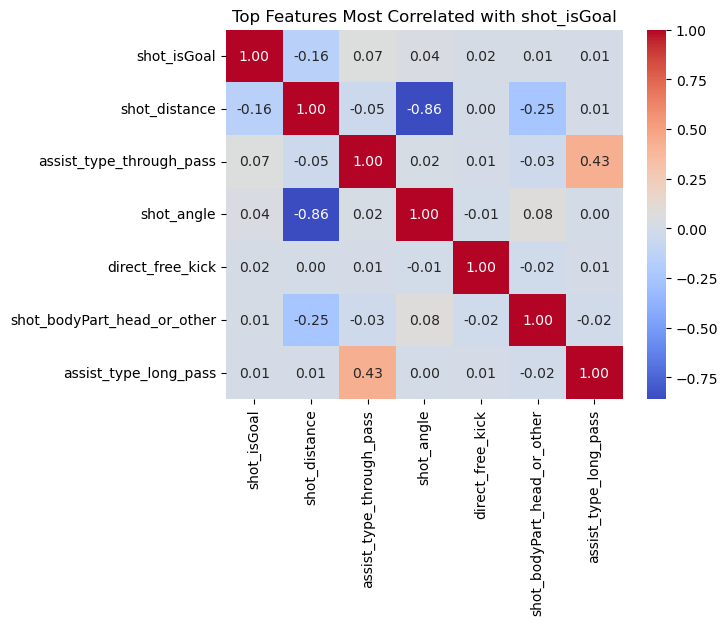

In [190]:
import seaborn as sns
import matplotlib.pyplot as plt


top_corr_goal_subset = corr_goal_subset['shot_isGoal'].abs().sort_values(ascending=False).head(10).index

sns.heatmap(shots[top_corr_goal_subset].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Top Features Most Correlated with shot_isGoal")
plt.show()

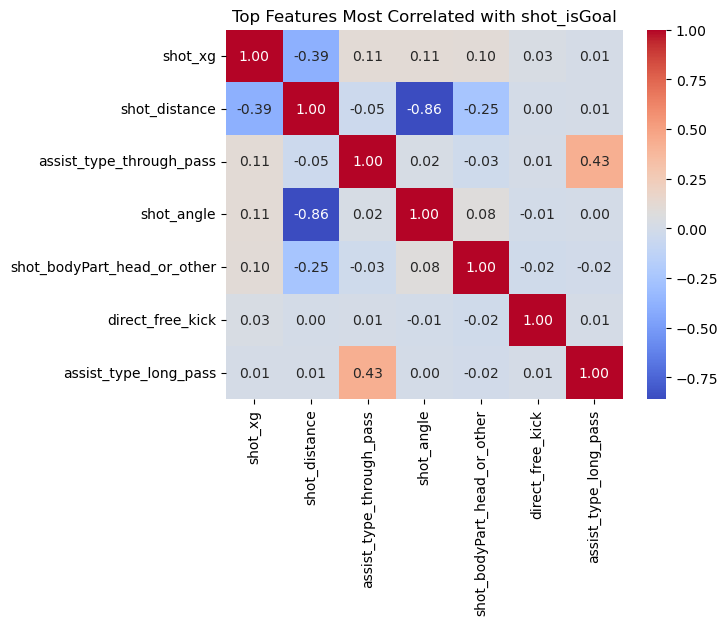

In [191]:
import seaborn as sns
import matplotlib.pyplot as plt


top_corr_xg_subset = corr_xg_subset['shot_xg'].abs().sort_values(ascending=False).head(10).index

sns.heatmap(shots[top_corr_xg_subset].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Top Features Most Correlated with shot_isGoal")
plt.show()

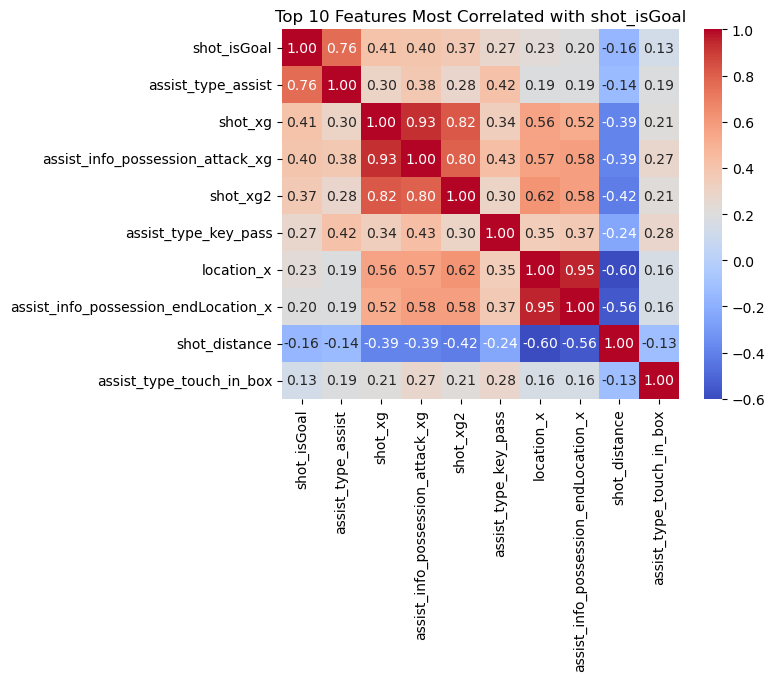

In [192]:
import seaborn as sns
import matplotlib.pyplot as plt


top_corr_goal = corr_goal['shot_isGoal'].abs().sort_values(ascending=False).head(10).index

sns.heatmap(shots[top_corr_goal].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Top 10 Features Most Correlated with shot_isGoal")
plt.show()


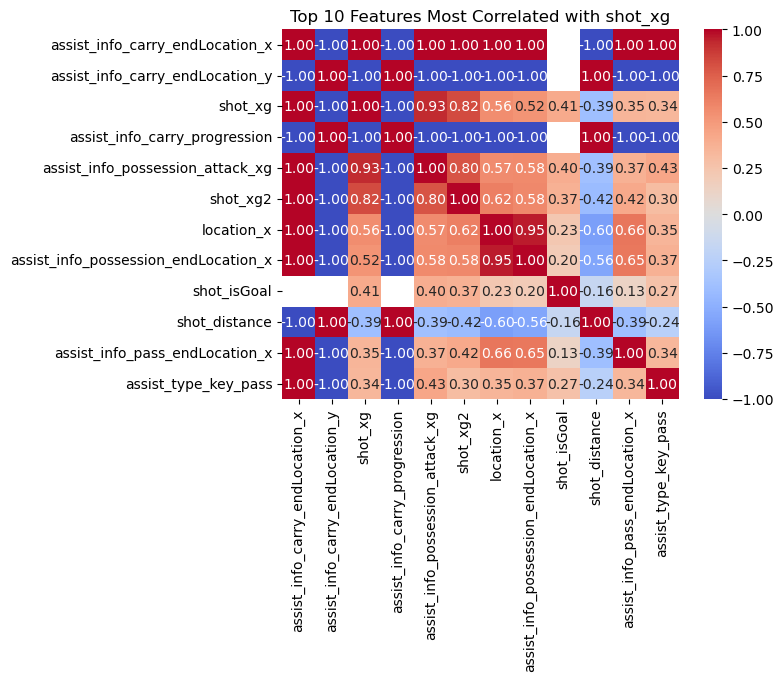

In [193]:
import seaborn as sns
import matplotlib.pyplot as plt

top_corr_xg = corr_xg['shot_xg'].abs().sort_values(ascending=False).head(12).index

sns.heatmap(shots[top_corr_xg].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Top 10 Features Most Correlated with shot_xg")
plt.show()


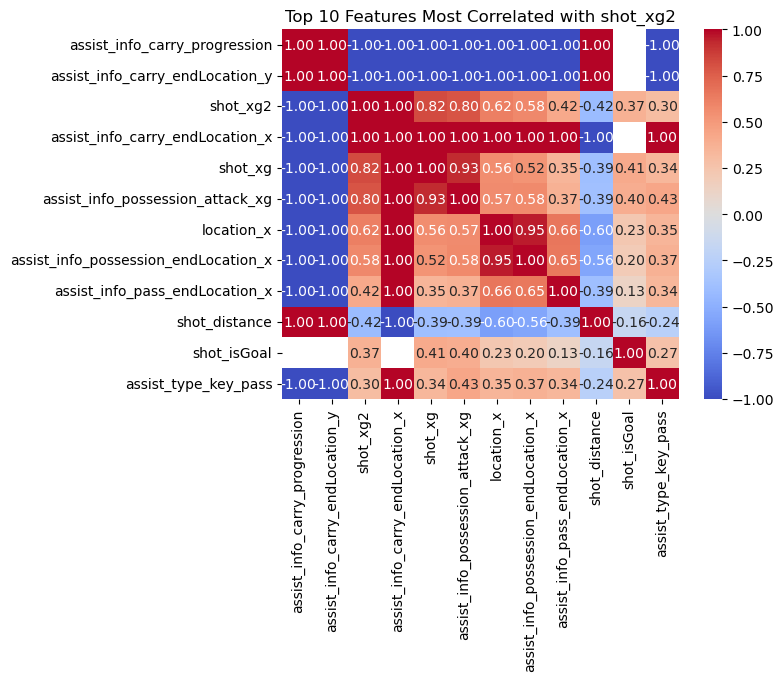

In [194]:
import seaborn as sns
import matplotlib.pyplot as plt

top_corr_xg2 = corr_xg2['shot_xg2'].abs().sort_values(ascending=False).head(12).index

sns.heatmap(shots[top_corr_xg2].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Top 10 Features Most Correlated with shot_xg2")
plt.show()


In [195]:
print("xg corr:", shots["shot_isGoal"].corr(shots["shot_xg"]))
print("xg2 corr:", shots["shot_isGoal"].corr(shots["shot_xg2"]))

xg corr: 0.40727563084802987
xg2 corr: 0.3721296562900698


In [196]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse_xg = np.sqrt(mean_squared_error(shots["shot_isGoal"], shots["shot_xg"]))
rmse_xg2 = np.sqrt(mean_squared_error(shots["shot_isGoal"], shots["shot_xg2"]))

print("RMSE xg:", rmse_xg)
print("RMSE xg2:", rmse_xg2)


mae_xg = mean_absolute_error(shots["shot_isGoal"], shots["shot_xg"])
mae_xg2 = mean_absolute_error(shots["shot_isGoal"], shots["shot_xg2"])

print("MAE xg:", mae_xg)
print("MAE xg2:", mae_xg2)

RMSE xg: 0.29729361064835275
RMSE xg2: 0.3025270767303866
MAE xg: 0.17760703719720078
MAE xg2: 0.1735013457742688


In [197]:
games_per_team = shots.groupby('team_name')['matchId'].nunique()


In [198]:
import pandas as pd

# 1. Total goals per team per match
goals_df = shots.groupby(['matchId', 'team_name'])['shot_isGoal'].sum().reset_index()

# 2. Get opponent team names per match
opponents = shots.groupby(['matchId', 'team_name'])['opponentTeam_name'].first().reset_index()
goals_df = goals_df.merge(opponents, on=['matchId', 'team_name'])

# 3. Rename for clarity
team_goals = goals_df.rename(columns={
    'team_name': 'team',
    'opponentTeam_name': 'opponent',
    'shot_isGoal': 'goals'
})

# 4. Merge to get both teams' goals in same row
merged = team_goals.merge(
    team_goals,
    left_on=['matchId', 'opponent'],
    right_on=['matchId', 'team'],
    suffixes=('', '_opponent')
)

# 5. Keep relevant columns
match_outcomes = merged[['matchId', 'team', 'opponent', 'goals', 'goals_opponent']]

# 6. Define result: win / draw / loss
def result(row):
    if row['goals'] > row['goals_opponent']:
        return 'win'
    elif row['goals'] < row['goals_opponent']:
        return 'loss'
    else:
        return 'draw'

match_outcomes['result'] = match_outcomes.apply(result, axis=1)

# 7. Count W/D/L per team
team_results = match_outcomes.groupby('team')['result'].value_counts().unstack(fill_value=0)

# Optional: sort by most wins
team_results = team_results.sort_values('win', ascending=False)

print(team_results)


result                 draw  loss  win
team                                  
PSG                       2     5   10
Real Madrid               1     4    8
Barcelona                 1     3    8
Arsenal                   4     2    7
Atlético Madrid           0     2    7
Borussia Dortmund         3     4    6
Liverpool                 1     2    6
Aston Villa               3     2    6
Internazionale            4     3    6
Bayern München            2     4    5
Feyenoord                 2     4    5
Lille                     3     2    4
Milan                     1     3    4
Juventus                  2     3    4
Monaco                    0     5    4
PSV                       4     4    4
Dinamo Zagreb             1     2    4
Bayer Leverkusen          1     2    4
Atalanta                  4     2    4
Real Betis                2     0    4
Manchester United         2     0    3
Benfica                   2     4    3
FCS Bucureşti             0     1    3
Stuttgart                

/var/folders/9q/c733hdkn4x7643llmv4jdfdw0000gn/T/ipykernel_41512/1874643267.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  match_outcomes['result'] = match_outcomes.apply(result, axis=1)


In [199]:
# Group by team
team_stats = shots.groupby('team_name').agg(
    total_shots=('shot_isGoal', 'count'),
    goals=('shot_isGoal', 'sum')
)

# Add accuracy + goal rate
team_stats['goal_rate'] = team_stats['goals'] / team_stats['total_shots']
team_stats = team_stats.sort_values('goal_rate', ascending=False)
team_stats['games_played'] = games_per_team
team_stats = team_stats.merge(team_results, left_index=True, right_index=True, how='left')



In [200]:
print(team_stats)

                       total_shots  goals  goal_rate  games_played  draw  \
team_name                                                                  
Beşiktaş                         9      3   0.333333             1     0   
Hoffenheim                       9      3   0.333333             1     1   
Víkingur Reykjavík               7      2   0.285714             1     0   
APOEL                            7      2   0.285714             1     1   
Elfsborg                         4      1   0.250000             1     0   
Malmö FF                         9      2   0.222222             1     0   
Qarabag                          5      1   0.200000             1     0   
Heidenheim                      10      2   0.200000             1     0   
HJK                             10      2   0.200000             1     1   
Lugano                          20      4   0.200000             2     0   
Fiorentina                      66     13   0.196970             6     1   
Dinamo Zagre

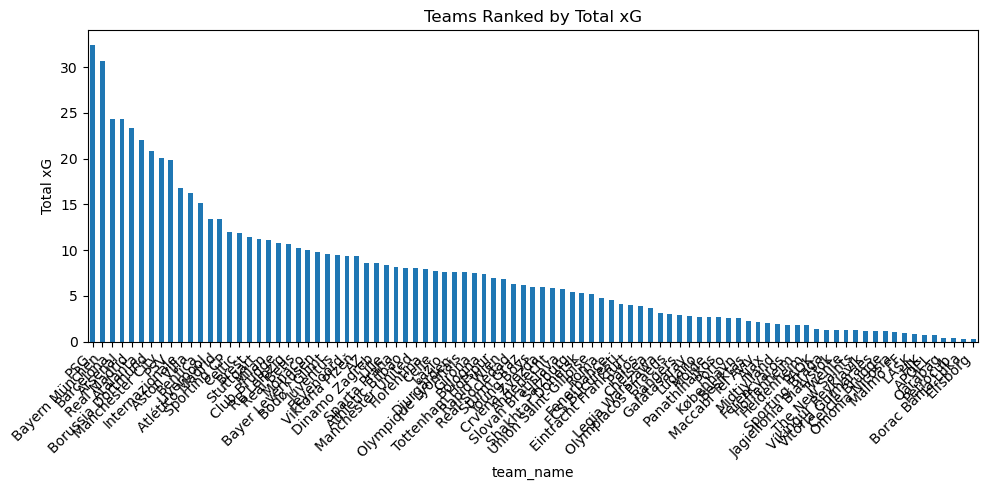

In [201]:
team_totals = (shots.groupby('team_name')['shot_xg']
                      .sum()
                      .sort_values(ascending=False))

plt.figure(figsize=(10, 5))
team_totals.plot(kind='bar')    # bar chart == ranked histogram
plt.ylabel('Total xG')
plt.title('Teams Ranked by Total xG')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [202]:
# print("xg corr:", team_totals["goals"].corr(team_totals["total_xg"]))
# print("xg2 corr:", team_totals["goals"].corr(team_totals["total_xg2"]))
team_totals.head(50)

team_name
PSG                   32.386827
Bayern München        30.615608
Barcelona             24.371334
Arsenal               24.359140
Real Madrid           23.354996
Atalanta              22.063755
Borussia Dortmund     20.870028
Manchester City       20.023405
PSV                   19.896424
Internazionale        16.764364
Aston Villa           16.231983
Benfica               15.123132
Liverpool             13.431448
Atlético Madrid       13.354661
Sporting CP           11.967226
Celtic                11.903748
Brest                 11.484974
Stuttgart             11.260389
Milan                 11.129207
Club Brugge           10.833136
RB Leipzig            10.709257
Real Betis            10.280051
Monaco                10.007856
Bayer Leverkusen       9.822690
Bodø / Glimt           9.599839
Juventus               9.489662
Feyenoord              9.391189
Viktoria Plzeň         9.391095
AZ                     8.627676
Dinamo Zagreb          8.559850
Lille                  8.43209

In [203]:
team_top10 = (shots.groupby('team_name')
                     .agg(total_xg=('shot_xg', 'sum'),
                          total_xg2=('shot_xg2', 'sum'),
                          goals=('shot_isGoal', 'sum'))
                     .sort_values('total_xg', ascending=False)
                     .head(10)
                     .reset_index())

player_top10 = (shots.groupby('player_name')
                      .agg(total_xg=('shot_xg', 'sum'),
                           goals=('shot_isGoal', 'sum'),
                           shots=('id', 'count'))
                      .sort_values('total_xg', ascending=False)
                      .head(10)
                      .reset_index())

In [204]:
print("xg corr:", team_top10["goals"].corr(team_top10["total_xg"]))
print("xg2 corr:", team_top10["goals"].corr(team_top10["total_xg2"]))

xg corr: 0.7576298814512596
xg2 corr: 0.7955857704229721


In [205]:
from sklearn.metrics import mean_absolute_error

mae_xg = mean_absolute_error(team_top10["goals"], team_top10["total_xg"])
mae_xg2 = mean_absolute_error(team_top10["goals"], team_top10["total_xg2"])

print("MAE xg:", mae_xg)
print("MAE xg2:", mae_xg2)


MAE xg: 3.2021231200000004
MAE xg2: 4.2411


In [206]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Your existing MAE calculations
mae_xg = mean_absolute_error(shots["shot_isGoal"], shots["shot_xg"])
mae_xg2 = mean_absolute_error(shots["shot_isGoal"], shots["shot_xg2"])

# Add R-squared calculations
r2_xg = r2_score(shots["shot_isGoal"], shots["shot_xg"])
r2_xg2 = r2_score(shots["shot_isGoal"], shots["shot_xg2"])


rmse_xg = np.sqrt(mean_squared_error(shots["shot_isGoal"], shots["shot_xg"]))
rmse_xg2 = np.sqrt(mean_squared_error(shots["shot_isGoal"], shots["shot_xg2"]))


print("RMSE xg:", rmse_xg)
print("RMSE xg2:", rmse_xg2)

print("MAE xg:", mae_xg)
print("MAE xg2:", mae_xg2)
print("R² xg:", r2_xg)
print("R² xg2:", r2_xg2)

RMSE xg: 0.29729361064835275
RMSE xg2: 0.3025270767303866
MAE xg: 0.17760703719720078
MAE xg2: 0.1735013457742688
R² xg: 0.16544798481079948
R² xg2: 0.13580696694952832


In [207]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_xg = np.sqrt(mean_squared_error(shots["shot_isGoal"], shots["shot_xg"]))
rmse_xg2 = np.sqrt(mean_squared_error(shots["shot_isGoal"], shots["shot_xg2"]))


print("RMSE xg:", rmse_xg)
print("RMSE xg2:", rmse_xg2)

from sklearn.metrics import mean_absolute_error


RMSE xg: 0.29729361064835275
RMSE xg2: 0.3025270767303866


In [208]:
shots['shot_xg2']       = pd.to_numeric(shots.get('shot_xg2'), errors='coerce')
shots['minute_exact']  = shots['minute'] + shots['second'] / 60


team_top10_xg2 = (shots.groupby('team_name')
                     .agg(total_xg2=('shot_xg2', 'sum'),
                          goals=('shot_isGoal', 'sum'))
                     .sort_values('total_xg2', ascending=False)
                     .head(10)
                     .reset_index())

player_top10_xg2 = (shots.groupby('player_name')
                      .agg(total_xg2=('shot_xg', 'sum'),
                           goals=('shot_isGoal', 'sum'),
                           shots=('id', 'count'))
                      .sort_values('total_xg2', ascending=False)
                      .head(10)
                      .reset_index())

In [209]:
print("\nTop-10 teams by total xG")
# print(team_top10.to_string(index=False))
team_top10.head()


Top-10 teams by total xG


,team_name,total_xg,total_xg2,goals
0,PSG,32.386827,30.702,36
1,Bayern München,30.615608,26.238,22
2,Barcelona,24.371334,21.094,31
3,Arsenal,24.359140,20.555,25
4,Real Madrid,23.354996,19.764,28


In [210]:
print("\nTop-10 teams by total xG2")
print(team_top10_xg2.to_string(index=False))


Top-10 teams by total xG2
        team_name  total_xg2  goals
              PSG     30.702     36
   Bayern München     26.238     22
        Barcelona     21.094     31
          Arsenal     20.555     25
      Real Madrid     19.764     28
         Atalanta     18.418     21
Borussia Dortmund     16.888     21
              PSV     16.554     19
  Manchester City     15.924     17
   Internazionale     14.072     14


In [211]:
team_summary = (shots.groupby('team_name')
                      .agg(shots=('id', 'count'),
                           goals=('shot_isGoal', 'sum'),
                           total_xg=('shot_xg', 'sum'),
                           avg_xg=('shot_xg', 'mean'),
                           med_xg=('shot_xg', 'median'),
                           total_xg2=('shot_xg2', 'sum'),
                           avg_xg2=('shot_xg2', 'mean'),
                           med_xg2=('shot_xg2', 'median'),
                           conv_rate=('shot_isGoal', 'mean'),
                           avg_dist=('shot_distance', 'mean'))
                      .round(2)
                      .sort_values('total_xg', ascending=False)
                      .head(10))

print("\nDetailed Top-10 team summary")
print(team_summary)


Detailed Top-10 team summary
                   shots  goals  total_xg  avg_xg  med_xg  total_xg2  avg_xg2  \
team_name                                                                       
PSG                  277     36     32.39    0.12    0.07      30.70     0.11   
Bayern München       243     22     30.62    0.13    0.08      26.24     0.11   
Barcelona            160     31     24.37    0.15    0.09      21.09     0.13   
Arsenal              142     25     24.36    0.17    0.12      20.56     0.14   
Real Madrid          170     28     23.35    0.14    0.09      19.76     0.12   
Atalanta             156     21     22.06    0.14    0.10      18.42     0.12   
Borussia Dortmund    160     21     20.87    0.13    0.08      16.89     0.11   
Manchester City      155     17     20.02    0.13    0.09      15.92     0.10   
PSV                  183     19     19.90    0.11    0.07      16.55     0.09   
Internazionale       133     14     16.76    0.13    0.07      14.07     0.11  

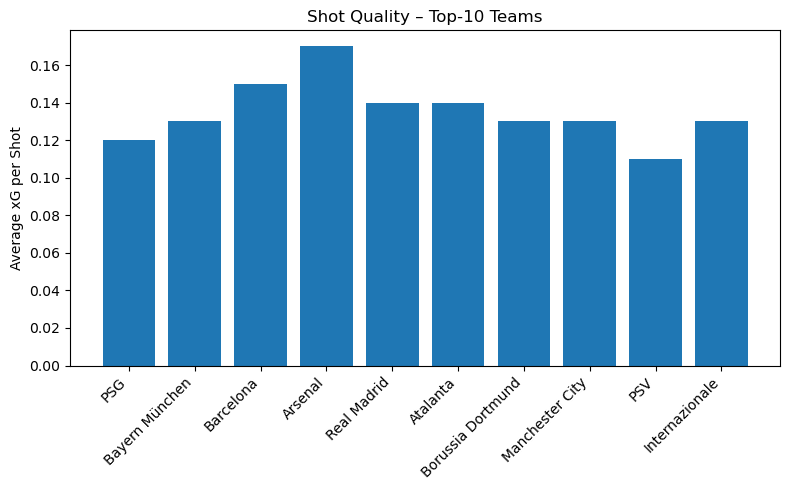

In [212]:
plt.figure(figsize=(8, 5))
plt.bar(team_summary.index, team_summary['avg_xg'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average xG per Shot')
plt.title('Shot Quality – Top-10 Teams')
plt.tight_layout()
plt.show()

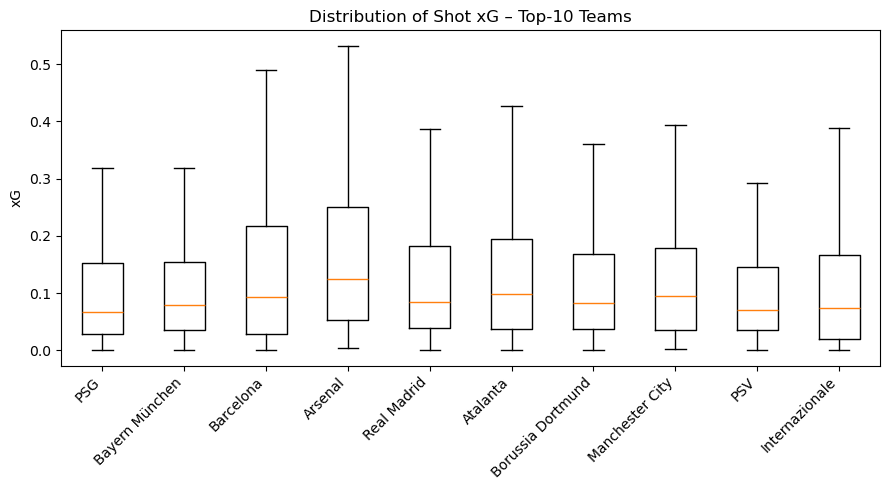

In [213]:
plt.figure(figsize=(9, 5))
box_data = [shots.loc[shots.team_name == t, 'shot_xg'] for t in team_summary.index]
plt.boxplot(box_data, labels=team_summary.index, showfliers=False)
plt.xticks(rotation=45, ha='right')
plt.ylabel('xG')
plt.title('Distribution of Shot xG – Top-10 Teams')
plt.tight_layout()
plt.show()

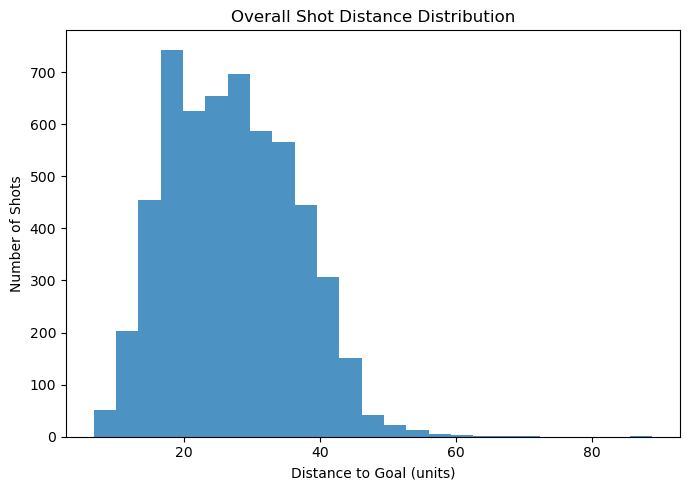

In [214]:
plt.figure(figsize=(7, 5))
plt.hist(shots['shot_distance'], bins=25, alpha=.8)
plt.xlabel('Distance to Goal (units)')
plt.ylabel('Number of Shots')
plt.title('Overall Shot Distance Distribution')
plt.tight_layout()
plt.show()

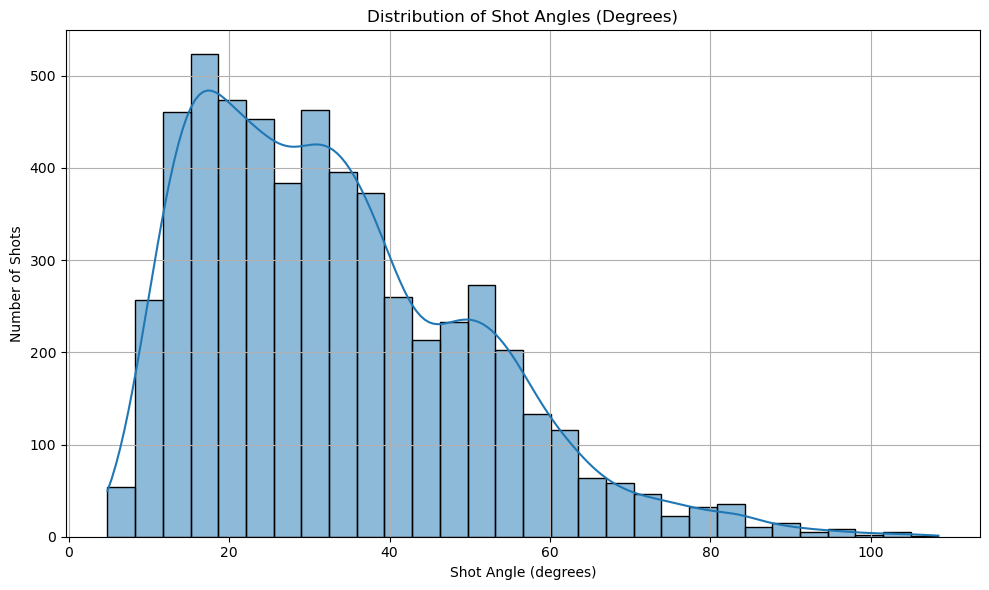

In [215]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(shots['shot_angle'], bins=30, kde=True)
plt.title("Distribution of Shot Angles (Degrees)")
plt.xlabel("Shot Angle (degrees)")
plt.ylabel("Number of Shots")
plt.grid(True)
plt.tight_layout()
plt.show()

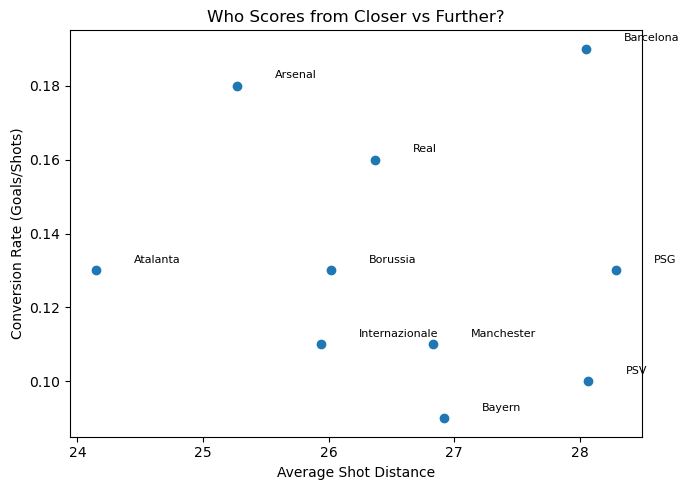

In [216]:
plt.figure(figsize=(7, 5))
plt.scatter(team_summary['avg_dist'], team_summary['conv_rate'])
for team, row in team_summary.iterrows():
    plt.text(row['avg_dist'] + 0.3,
             row['conv_rate'] + 0.002,
             team.split(' ')[0],
             fontsize=8)
plt.xlabel('Average Shot Distance')
plt.ylabel('Conversion Rate (Goals/Shots)')
plt.title('Who Scores from Closer vs Further?')
plt.tight_layout()
plt.show()

In [217]:
print("\nTop-10 players by total xG")
print(player_top10.to_string(index=False))


Top-10 players by total xG
    player_name  total_xg  goals  shots
        H. Kane  7.828236      7     43
      K. Mbappé  6.768256      7     41
     O. Dembélé  6.409337      8     58
    S. Guirassy  6.109559      7     30
     E. Haaland  6.092070      6     30
     B. Barcola  6.016620      3     29
       Raphinha  5.348741     11     37
Vinícius Júnior  4.464949      7     32
     L. de Jong  4.419090      2     23
    V. Pavlidis  4.382569      5     18


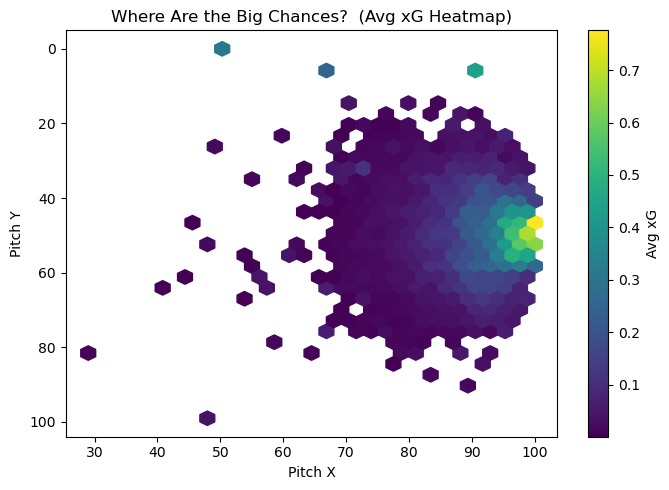

In [218]:
plt.figure(figsize=(7, 5))

valid = shots[['location_x', 'location_y', 'shot_xg']].dropna()

hb = plt.hexbin(valid['location_x'],
                valid['location_y'],
                C=valid['shot_xg'],
                reduce_C_function=np.mean, 
                gridsize=30,
                cmap='viridis')

plt.colorbar(hb, label='Avg xG')
plt.gca().invert_yaxis()
plt.xlabel('Pitch X')
plt.ylabel('Pitch Y')
plt.title('Where Are the Big Chances?  (Avg xG Heatmap)')
plt.tight_layout()
plt.show()


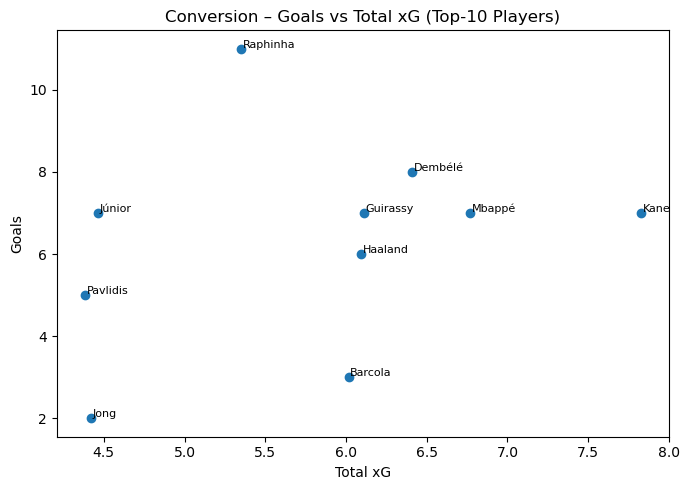

In [219]:
plt.figure(figsize=(7, 5))
plt.scatter(player_top10['total_xg'], player_top10['goals'])
for _, row in player_top10.iterrows():
    last = row['player_name'].split(' ')[-1]
    plt.text(row['total_xg'] + 0.01, row['goals'] + 0.02, last, fontsize=8)
plt.title('Conversion – Goals vs Total xG (Top-10 Players)')
plt.xlabel('Total xG')
plt.ylabel('Goals')
plt.tight_layout()
plt.show()

In [220]:
possible = [c for c in shots.columns
            if c.lower() in ['match_id', 'matchid', 'fixture_id', 'game_id']]
match_col = possible[0]          # pick the first hit



/var/folders/9q/c733hdkn4x7643llmv4jdfdw0000gn/T/ipykernel_41512/136262247.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df.assign(cumu=df['shot_xg'].cumsum()))


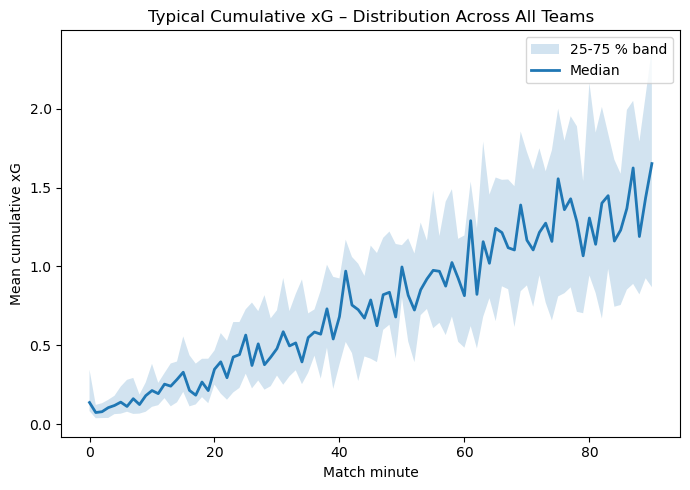

In [221]:
# create integer minute once
shots['minute_int'] = shots['minute_exact'].round().astype(int)

# per-match cumulative xG
match_cum = (shots.sort_values(['team_name', match_col, 'minute_int'])
                   .groupby(['team_name', match_col])
                   .apply(lambda df: df.assign(cumu=df['shot_xg'].cumsum()))
                   .reset_index(drop=True))

# average across matches
mean_curve = (match_cum.groupby(['team_name', 'minute_int'])['cumu']
                       .mean()
                       .reset_index())

pivot = (mean_curve.pivot(index='minute_int',
                          columns='team_name',
                          values='cumu')
                    .reindex(range(0, 91)))      # ensure full minute index

median = pivot.median(axis=1)
p25    = pivot.quantile(0.25, axis=1)
p75    = pivot.quantile(0.75, axis=1)

plt.figure(figsize=(7, 5))
plt.fill_between(pivot.index, p25, p75, alpha=0.2, label='25-75 % band')
plt.plot(pivot.index, median, linewidth=2, label='Median')

plt.xlabel('Match minute')
plt.ylabel('Mean cumulative xG')
plt.title('Typical Cumulative xG – Distribution Across All Teams')
plt.legend()
plt.tight_layout()
plt.show()


/var/folders/9q/c733hdkn4x7643llmv4jdfdw0000gn/T/ipykernel_41512/2218167672.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df.assign(cumu=df['shot_xg'].cumsum()))


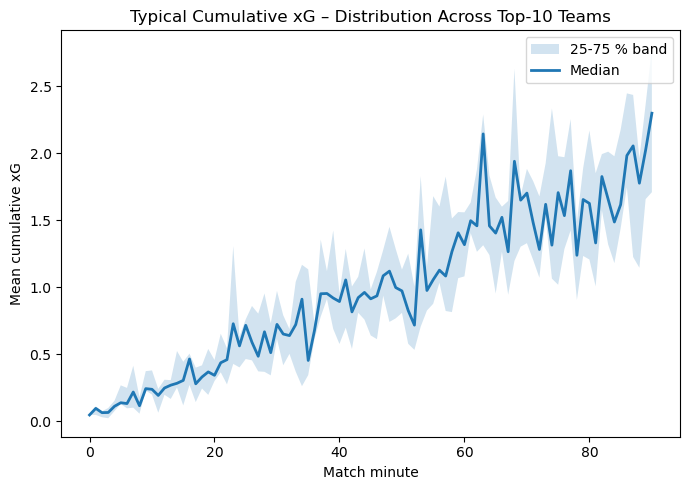

In [222]:
top10_names = team_top10['team_name'].tolist()       
shots_t10   = shots[shots['team_name'].isin(top10_names)].copy()

shots_t10['minute_int'] = shots_t10['minute_exact'].round().astype(int)

match_cum = (shots_t10.sort_values(['team_name', match_col, 'minute_int'])
                    .groupby(['team_name', match_col])
                    .apply(lambda df: df.assign(cumu=df['shot_xg'].cumsum()))
                    .reset_index(drop=True))

mean_curve = (match_cum.groupby(['team_name', 'minute_int'])['cumu']
                       .mean()
                       .reset_index())


pivot  = (mean_curve.pivot(index='minute_int',
                           columns='team_name',
                           values='cumu')
                     .reindex(range(0, 91)))

median = pivot.median(axis=1)
p25    = pivot.quantile(0.25, axis=1)
p75    = pivot.quantile(0.75, axis=1)

plt.figure(figsize=(7, 5))
plt.fill_between(pivot.index, p25, p75, alpha=0.2, label='25-75 % band')
plt.plot(pivot.index, median, linewidth=2, label='Median')

plt.xlabel('Match minute')
plt.ylabel('Mean cumulative xG')
plt.title('Typical Cumulative xG – Distribution Across Top-10 Teams')
plt.legend()
plt.tight_layout()
plt.show()


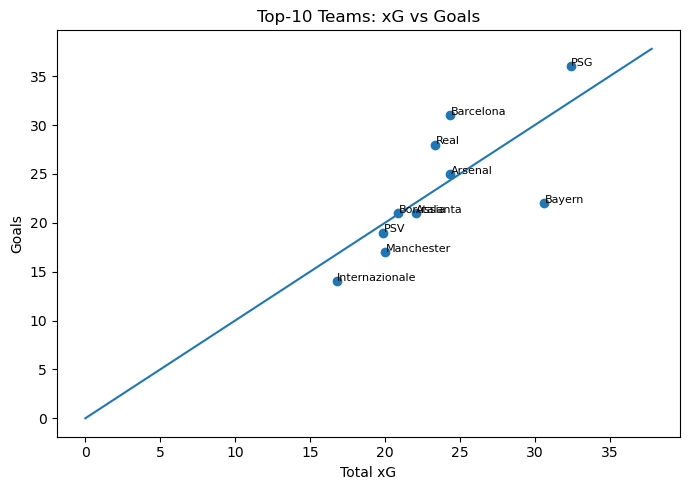

In [223]:
plt.figure(figsize=(7, 5))
plt.scatter(team_top10['total_xg'], team_top10['goals'])
max_val = max(team_top10['total_xg'].max(), team_top10['goals'].max()) * 1.05
plt.plot([0, max_val], [0, max_val])        # 45° reference line
for _, row in team_top10.iterrows():
    plt.text(row['total_xg'] + 0.03,
             row['goals']   + 0.03,
             row['team_name'].split(' ')[0],
             fontsize=8)
plt.xlabel('Total xG')
plt.ylabel('Goals')
plt.title('Top-10 Teams: xG vs Goals')
plt.tight_layout()
plt.show()

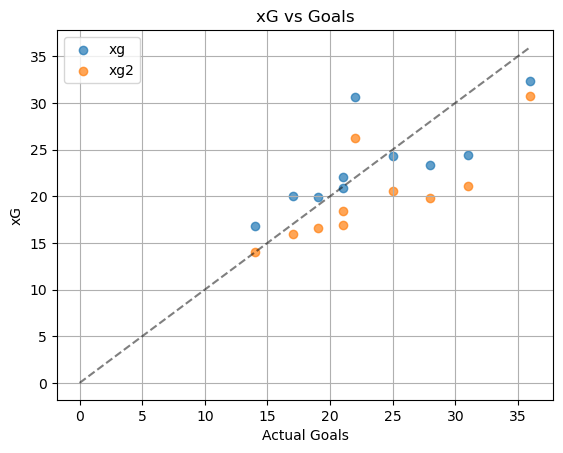

In [224]:
import matplotlib.pyplot as plt

plt.scatter(team_top10["goals"], team_top10["total_xg"], label="xg", alpha=0.7)
plt.scatter(team_top10_xg2["goals"], team_top10_xg2["total_xg2"], label="xg2", alpha=0.7)
plt.plot([0, team_top10["goals"].max()], [0, team_top10["goals"].max()], 'k--', alpha=0.5)
plt.xlabel("Actual Goals")
plt.ylabel("xG")
plt.legend()
plt.title("xG vs Goals")
plt.grid(True)
plt.show()


In [225]:
# Basic stats
print("BASIC STATS:")
print(f"Total shots: {len(shots)}")
print(f"Total goals: {shots['shot_isGoal'].sum()}")
print(f"Conversion rate: {shots['shot_isGoal'].mean():.1%}")
print(f"Teams: {shots['team_name'].nunique()}")
print(f"Distance: {shots['shot_distance'].mean()}")

# Distance analysis
print("\nCONVERSION BY DISTANCE:")
shots['dist_bin'] = pd.cut(shots['shot_distance'], bins=[0,10,20,30,100], labels=['<10m','10-20m','20-30m','>30m'])
print(shots.groupby('dist_bin')['shot_isGoal'].agg(['count', 'mean']))

# Top teams
print("\nTOP 10 TEAMS:")
team_stats = shots.groupby('team_name').agg({
    'shot_isGoal': ['count', 'sum', 'mean'],
    'shot_xg': ['sum', 'mean'],
    'shot_distance': 'mean'
}).round(3)
print(team_stats.sort_values(('shot_xg', 'sum'), ascending=False).head(10))

# Correlations
print("\nTOP CORRELATIONS WITH GOALS:")
corrs = shots.select_dtypes(include=[np.number]).corr()['shot_isGoal'].abs().sort_values(ascending=False)
print(corrs.head(8))

# xG comparison
print(f"\nXG COMPARISON:")
print(f"xG correlation with goals: {shots['shot_isGoal'].corr(shots['shot_xg']):.3f}")
print(f"xG2 correlation with goals: {shots['shot_isGoal'].corr(shots['shot_xg2']):.3f}")

BASIC STATS:
Total shots: 5573
Total goals: 671
Conversion rate: 12.0%
Teams: 91
Distance: 27.11487864568609

CONVERSION BY DISTANCE:
          count      mean
dist_bin                 
<10m         67  0.149254
10-20m     1446  0.174274
20-30m     1984  0.142137
>30m       2076  0.061175

TOP 10 TEAMS:
                  shot_isGoal            shot_xg        shot_distance
                        count sum   mean     sum   mean          mean
team_name                                                            
PSG                       277  36  0.130  32.387  0.117        28.290
Bayern München            243  22  0.091  30.616  0.126        26.921
Barcelona                 160  31  0.194  24.371  0.152        28.053
Arsenal                   142  25  0.176  24.359  0.172        25.267
Real Madrid               170  28  0.165  23.355  0.137        26.368
Atalanta                  156  21  0.135  22.064  0.141        24.153
Borussia Dortmund         160  21  0.131  20.870  0.130        26

/var/folders/9q/c733hdkn4x7643llmv4jdfdw0000gn/T/ipykernel_41512/1252923318.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(shots.groupby('dist_bin')['shot_isGoal'].agg(['count', 'mean']))


In [226]:
# # Export your main processed dataset
# shots.to_csv('shots_processed.csv', index=False)

# # Or key summary tables
# team_summary.to_csv('team_summary.csv', index=False)